In [1]:
!wget -q --show-progress https://files.grouplens.org/datasets/movielens/ml-1m.zip
!unzip -q ml-1m.zip
!pip install -q xgboost shap scikit-learn scipy
print('✓ ready')

ml-1m.zip           100%[===================>]   5.64M  3.43MB/s    in 1.6s    
✓ ready


## 1. Data Loader

In [2]:
# ── Cell 1: Data Loader (same as v1) ─────────────────────────

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import warnings
from scipy import stats as sp
warnings.filterwarnings('ignore')

LIKE_THRESHOLD = 4
RANDOM_SEED    = 42

ALL_GENRES = [
    'Action','Adventure','Animation','Childrens','Comedy','Crime',
    'Documentary','Drama','Fantasy','FilmNoir','Horror','Musical',
    'Mystery','Romance','SciFi','Thriller','War','Western',
]

def load_ratings(path='ml-1m/ratings.dat'):
    df = pd.read_csv(path, sep='::', engine='python', header=None,
                     names=['user_id','movie_id','rating','timestamp'])
    df['like']      = (df['rating'] >= LIKE_THRESHOLD).astype(int)
    df['timestamp'] = df['timestamp'].astype(int)
    df = df.sort_values(['user_id','timestamp']).reset_index(drop=True)
    n_u, n_m = df['user_id'].nunique(), df['movie_id'].nunique()
    print(f'[ratings] {len(df):,} | {n_u:,} users | {n_m:,} movies | '
          f'like={df["like"].mean():.1%} | density={len(df)/(n_u*n_m):.2%}')
    return df

def load_movies(path='ml-1m/movies.dat'):
    df = pd.read_csv(path, sep='::', engine='python', header=None,
                     names=['movie_id','title','genres'], encoding='latin-1')
    df['year'] = df['title'].str.extract(r'\((\d{4})\)$').astype(float)
    raw = df['genres'].str.replace("Children's",'Childrens',regex=False)\
                      .str.replace('Film-Noir','FilmNoir',regex=False)
    for g in ALL_GENRES:
        df[f'genre_{g}'] = raw.str.contains(g, regex=False).astype(int)
    genre_cols = [c for c in df.columns if c.startswith('genre_')]
    df['n_genres'] = df[genre_cols].sum(axis=1)
    print(f'[movies]  {len(df):,} movies | {len(genre_cols)} genres | '
          f'year {int(df["year"].min())}–{int(df["year"].max())}')
    return df

def load_users(path='ml-1m/users.dat'):
    df = pd.read_csv(path, sep='::', engine='python', header=None,
                     names=['user_id','gender','age','occupation','zip'])
    df['gender_enc'] = (df['gender'] == 'M').astype(int)
    df['age_enc']    = df['age'].map(
        {1:0,18:1,25:2,35:3,45:4,50:5,56:6}).fillna(0).astype(int)
    print(f'[users]   {len(df):,} users | M={df["gender_enc"].mean():.1%} | '
          f'occupations={df["occupation"].nunique()}')
    return df

def temporal_split_per_user(df, val_ratio=0.10, test_ratio=0.10):
    train_list, val_list, test_list = [], [], []
    for uid, grp in df.groupby('user_id'):
        grp = grp.sort_values('timestamp')
        n   = len(grp)
        train_end = int(n * (1 - val_ratio - test_ratio))
        val_end   = int(n * (1 - test_ratio))
        if train_end == 0:       train_end = 1
        if val_end <= train_end: val_end   = train_end + 1
        if val_end >= n:         val_end   = n - 1
        train_list.append(grp.iloc[:train_end])
        val_list.append(grp.iloc[train_end:val_end])
        test_list.append(grp.iloc[val_end:])

    train = pd.concat(train_list).reset_index(drop=True)
    val   = pd.concat(val_list).reset_index(drop=True)
    test  = pd.concat(test_list).reset_index(drop=True)
    print(f'[per-user split] train {len(train):,} | '
          f'val {len(val):,} | test {len(test):,}')
    return train, val, test

ratings = load_ratings()
movies  = load_movies()
users   = load_users()
train, val, test = temporal_split_per_user(ratings)

[ratings] 1,000,209 | 6,040 users | 3,706 movies | like=57.5% | density=4.47%
[movies]  3,883 movies | 18 genres | year 1919–2000
[users]   6,040 users | M=71.7% | occupations=21
[per-user split] train 797,758 | val 99,692 | test 102,759


In [3]:
user_counts = ratings.groupby('user_id').size()
print(user_counts.describe())
print("Mean ratings per user:", user_counts.mean())
print("Median ratings per user:", user_counts.median())

count    6040.000000
mean      165.597517
std       192.747029
min        20.000000
25%        44.000000
50%        96.000000
75%       208.000000
max      2314.000000
dtype: float64
Mean ratings per user: 165.5975165562914
Median ratings per user: 96.0


##2.2 Data Preparation for GRU4Rec

In [4]:
# ── Cell 2: GRU4Rec Data Preparation ─────────────────────────

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import roc_auc_score, log_loss

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')

# ── ID mapping (movie_id → contiguous index) ─────────────────
# 0 is reserved as padding for sequences shorter than max_len
all_movie_ids = sorted(ratings['movie_id'].unique())
mid2idx = {mid: i+1 for i, mid in enumerate(all_movie_ids)}  # 1-indexed
idx2mid = {i: mid for mid, i in mid2idx.items()}
n_items = len(all_movie_ids) + 1  # +1 for padding idx=0

ratings['movie_idx'] = ratings['movie_id'].map(mid2idx)
train['movie_idx']   = train['movie_id'].map(mid2idx)
val['movie_idx']     = val['movie_id'].map(mid2idx)
test['movie_idx']    = test['movie_id'].map(mid2idx)

print(f'n_items (with padding): {n_items}')

# ── Build user sequences from TRAIN only ─────────────────────
# For each user: ordered list of (movie_idx, like) from train set

user_sequences = {}
for uid, grp in train.sort_values(['user_id','timestamp']).groupby('user_id'):
    user_sequences[uid] = list(zip(grp['movie_idx'].values,
                                   grp['like'].values))

seq_lens = [len(v) for v in user_sequences.values()]
print(f'Users with sequences: {len(user_sequences):,}')
print(f'Sequence length: min={min(seq_lens)}, '
      f'median={int(np.median(seq_lens))}, '
      f'max={max(seq_lens)}')


# ── Sequence Dataset ─────────────────────────────────────────
# For each (user, target_movie, label) in val/test:
#   input  = user's last `max_len` movies from train (before target)
#   target = (target_movie_idx, like)

class SeqDataset(Dataset):
    """
    Given a split (val or test), for each row:
      - Look up user's train history
      - Take last max_len movie IDs as input sequence
      - Target = (movie_idx, like label)
    """
    def __init__(self, df, user_sequences, max_len=20):
        self.samples  = []
        self.max_len  = max_len

        for _, row in df.iterrows():
            uid  = row['user_id']
            if uid not in user_sequences:
                continue
            seq = user_sequences[uid]
            if len(seq) < 1:
                continue

            # History: movie IDs only (not labels)
            hist_ids = [s[0] for s in seq]

            # Truncate to last max_len
            if len(hist_ids) > max_len:
                hist_ids = hist_ids[-max_len:]

            self.samples.append({
                'hist':       hist_ids,
                'target_idx': row['movie_idx'],
                'label':      row['like'],
            })

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        s = self.samples[idx]
        hist = s['hist']

        # Pad to max_len (left-pad with 0)
        pad_len = self.max_len - len(hist)
        padded  = [0] * pad_len + hist

        return {
            'hist':       torch.tensor(padded, dtype=torch.long),
            'target_idx': torch.tensor(s['target_idx'], dtype=torch.long),
            'label':      torch.tensor(s['label'], dtype=torch.float),
            'seq_len':    torch.tensor(len(hist), dtype=torch.long),
        }


# For train set: build sequences where each step is a training sample
# (history up to step t → predict step t)

class TrainSeqDataset(Dataset):
    """
    For training: expand each user's train history into multiple samples.
    At each position t (t >= 1):
      input  = movies[0:t] (last max_len)
      target = (movie[t], like[t])
    """
    def __init__(self, user_sequences, max_len=20, min_hist=1):
        self.samples = []
        self.max_len = max_len

        for uid, seq in user_sequences.items():
            if len(seq) < 2:
                continue
            movie_ids = [s[0] for s in seq]
            labels    = [s[1] for s in seq]

            for t in range(min_hist, len(seq)):
                hist = movie_ids[:t]
                if len(hist) > max_len:
                    hist = hist[-max_len:]

                self.samples.append({
                    'hist':       hist,
                    'target_idx': movie_ids[t],
                    'label':      labels[t],
                })

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        s = self.samples[idx]
        hist = s['hist']
        pad_len = self.max_len - len(hist)
        padded  = [0] * pad_len + hist

        return {
            'hist':       torch.tensor(padded, dtype=torch.long),
            'target_idx': torch.tensor(s['target_idx'], dtype=torch.long),
            'label':      torch.tensor(s['label'], dtype=torch.float),
            'seq_len':    torch.tensor(len(hist), dtype=torch.long),
        }


# ── Build datasets ───────────────────────────────────────────

MAX_LEN = 20

train_ds = TrainSeqDataset(user_sequences, max_len=MAX_LEN)
val_ds   = SeqDataset(val,  user_sequences, max_len=MAX_LEN)
test_ds  = SeqDataset(test, user_sequences, max_len=MAX_LEN)

print(f'\nDataset sizes:')
print(f'  train: {len(train_ds):,} samples')
print(f'  val:   {len(val_ds):,} samples')
print(f'  test:  {len(test_ds):,} samples')

train_loader = DataLoader(train_ds, batch_size=512, shuffle=True,
                          num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=1024, shuffle=False,
                          num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_ds,  batch_size=1024, shuffle=False,
                          num_workers=2, pin_memory=True)

print(f'  train batches: {len(train_loader)}')
print('✓ Data preparation complete')

Device: cuda
n_items (with padding): 3707
Users with sequences: 6,040
Sequence length: min=16, median=76, max=1851

Dataset sizes:
  train: 791,718 samples
  val:   99,692 samples
  test:  102,759 samples
  train batches: 1547
✓ Data preparation complete


##2.3 GRU Model Setup

In [5]:
# ── Cell 3: GRU4Rec Model ────────────────────────────────────

class GRU4Rec(nn.Module):
    """
    GRU-based sequential recommendation model.
    Input:  sequence of movie IDs (user's history)
    Output: P(like | history, target_movie)

    Architecture:
      movie_id → Embedding → GRU → last hidden state
      target_movie_id → Embedding
      concat(hidden, target_embed) → MLP → sigmoid → P(like)
    """
    def __init__(self, n_items, embed_dim=64, hidden_dim=128,
                 n_layers=1, dropout=0.2):
        super().__init__()
        self.item_embed = nn.Embedding(n_items, embed_dim, padding_idx=0)
        self.gru = nn.GRU(embed_dim, hidden_dim,
                          num_layers=n_layers,
                          batch_first=True,
                          dropout=dropout if n_layers > 1 else 0)
        self.dropout = nn.Dropout(dropout)

        # MLP: concat(gru_hidden, target_embed) → P(like)
        self.fc = nn.Sequential(
            nn.Linear(hidden_dim + embed_dim, 128),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(128, 1),
        )

    def forward(self, hist, target_idx, seq_len=None):
        """
        hist:       (B, max_len) - padded movie ID sequence
        target_idx: (B,) - target movie ID
        seq_len:    (B,) - actual sequence lengths (unused for now,
                           GRU processes full padded sequence)
        """
        # Encode history
        hist_emb = self.item_embed(hist)        # (B, T, embed_dim)
        gru_out, _ = self.gru(hist_emb)         # (B, T, hidden_dim)

        # Use last non-padded hidden state
        # Simple approach: take the last position
        # (padding is left-padded, so last position = most recent)
        h_last = gru_out[:, -1, :]              # (B, hidden_dim)

        # Encode target movie
        target_emb = self.item_embed(target_idx) # (B, embed_dim)

        # Predict
        combined = torch.cat([h_last, target_emb], dim=1)
        combined = self.dropout(combined)
        logit    = self.fc(combined).squeeze(-1)  # (B,)
        return logit

##2.4 GRU4Rec Training Loop

In [6]:
# ── Cell 4: Training Loop ────────────────────────────────────

def train_one_epoch(model, loader, optimizer, criterion, device):
    model.train()
    total_loss = 0
    n_samples  = 0
    for batch in loader:
        hist   = batch['hist'].to(device)
        target = batch['target_idx'].to(device)
        label  = batch['label'].to(device)

        logit = model(hist, target)
        loss  = criterion(logit, label)

        optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()

        total_loss += loss.item() * len(label)
        n_samples  += len(label)

    return total_loss / n_samples


@torch.no_grad()
def evaluate(model, loader, criterion, device):
    model.eval()
    all_probs  = []
    all_labels = []
    total_loss = 0
    n_samples  = 0

    for batch in loader:
        hist   = batch['hist'].to(device)
        target = batch['target_idx'].to(device)
        label  = batch['label'].to(device)

        logit = model(hist, target)
        loss  = criterion(logit, label)
        prob  = torch.sigmoid(logit)

        total_loss += loss.item() * len(label)
        n_samples  += len(label)
        all_probs.extend(prob.cpu().numpy())
        all_labels.extend(label.cpu().numpy())

    avg_loss = total_loss / n_samples
    probs    = np.array(all_probs)
    labels   = np.array(all_labels)
    auc      = roc_auc_score(labels, probs)
    ll       = log_loss(labels, probs)
    return dict(loss=avg_loss, auc=auc, logloss=ll,
                probs=probs, labels=labels)

## 2.5 GRU4Rec Baseline Training

In [11]:
# ============================================================
# Reproducibility
# ============================================================

import random
import numpy as np
import torch

RANDOM_SEED = 42

random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)
torch.cuda.manual_seed_all(RANDOM_SEED)

# Make CuDNN more deterministic (may slightly reduce speed)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

print("Random seed set to", RANDOM_SEED)

Random seed set to 42


In [12]:
# ── Cell 5: Run Baseline Training ────────────────────────────

# Hyperparameters
EMBED_DIM  = 64
HIDDEN_DIM = 128
N_LAYERS   = 1
DROPOUT    = 0.2
LR         = 1e-3
EPOCHS     = 20
PATIENCE   = 5   # early stopping

model = GRU4Rec(n_items, embed_dim=EMBED_DIM, hidden_dim=HIDDEN_DIM,
                n_layers=N_LAYERS, dropout=DROPOUT).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=LR)
criterion = nn.BCEWithLogitsLoss()

print(f'Model parameters: {sum(p.numel() for p in model.parameters()):,}')
print(f'Config: embed={EMBED_DIM}, hidden={HIDDEN_DIM}, '
      f'layers={N_LAYERS}, dropout={DROPOUT}, lr={LR}')
print(f'Training for up to {EPOCHS} epochs (patience={PATIENCE})')
print()

history = {'train_loss': [], 'val_loss': [], 'val_auc': [], 'val_ll': []}
best_val_auc = 0
best_epoch   = 0
no_improve   = 0

for epoch in range(1, EPOCHS + 1):
    # Train
    train_loss = train_one_epoch(model, train_loader, optimizer,
                                 criterion, device)
    # Validate
    val_res = evaluate(model, val_loader, criterion, device)

    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_res['loss'])
    history['val_auc'].append(val_res['auc'])
    history['val_ll'].append(val_res['logloss'])

    improved = '★' if val_res['auc'] > best_val_auc else ''
    print(f'  Epoch {epoch:2d}/{EPOCHS}  '
          f'train_loss={train_loss:.4f}  '
          f'val_AUC={val_res["auc"]:.4f}  '
          f'val_LL={val_res["logloss"]:.4f}  {improved}')

    # Early stopping
    if val_res['auc'] > best_val_auc:
        best_val_auc = val_res['auc']
        best_epoch   = epoch
        no_improve   = 0
        # Save best model
        torch.save(model.state_dict(), 'gru4rec_best.pt')
    else:
        no_improve += 1
        if no_improve >= PATIENCE:
            print(f'\n  Early stopping at epoch {epoch} '
                  f'(best={best_epoch}, AUC={best_val_auc:.4f})')
            break

# Load best model and evaluate on test
model.load_state_dict(torch.load('gru4rec_best.pt'))
test_res = evaluate(model, test_loader, criterion, device)

print(f'\n── GRU4Rec Baseline Results ─────────────────────────')
print(f'  Best epoch: {best_epoch}')
print(f'  [val ] AUC={best_val_auc:.4f}')
print(f'  [test] AUC={test_res["auc"]:.4f}  '
      f'LogLoss={test_res["logloss"]:.4f}')
print(f'\n  XGBoost reference: AUC=0.7997 (SVD-only=0.7995)')

Model parameters: 336,577
Config: embed=64, hidden=128, layers=1, dropout=0.2, lr=0.001
Training for up to 20 epochs (patience=5)

  Epoch  1/20  train_loss=0.6214  val_AUC=0.7013  val_LL=0.6311  ★
  Epoch  2/20  train_loss=0.6002  val_AUC=0.7183  val_LL=0.6185  ★
  Epoch  3/20  train_loss=0.5877  val_AUC=0.7212  val_LL=0.6167  ★
  Epoch  4/20  train_loss=0.5707  val_AUC=0.7287  val_LL=0.6093  ★
  Epoch  5/20  train_loss=0.5534  val_AUC=0.7299  val_LL=0.6091  ★
  Epoch  6/20  train_loss=0.5386  val_AUC=0.7338  val_LL=0.6114  ★
  Epoch  7/20  train_loss=0.5268  val_AUC=0.7349  val_LL=0.6124  ★
  Epoch  8/20  train_loss=0.5171  val_AUC=0.7358  val_LL=0.6067  ★
  Epoch  9/20  train_loss=0.5087  val_AUC=0.7370  val_LL=0.6163  ★
  Epoch 10/20  train_loss=0.5009  val_AUC=0.7341  val_LL=0.6153  
  Epoch 11/20  train_loss=0.4942  val_AUC=0.7336  val_LL=0.6243  
  Epoch 12/20  train_loss=0.4867  val_AUC=0.7289  val_LL=0.6395  
  Epoch 13/20  train_loss=0.4804  val_AUC=0.7258  val_LL=0.6427  
  

## 2.6 GRU4Rec Learning Curve

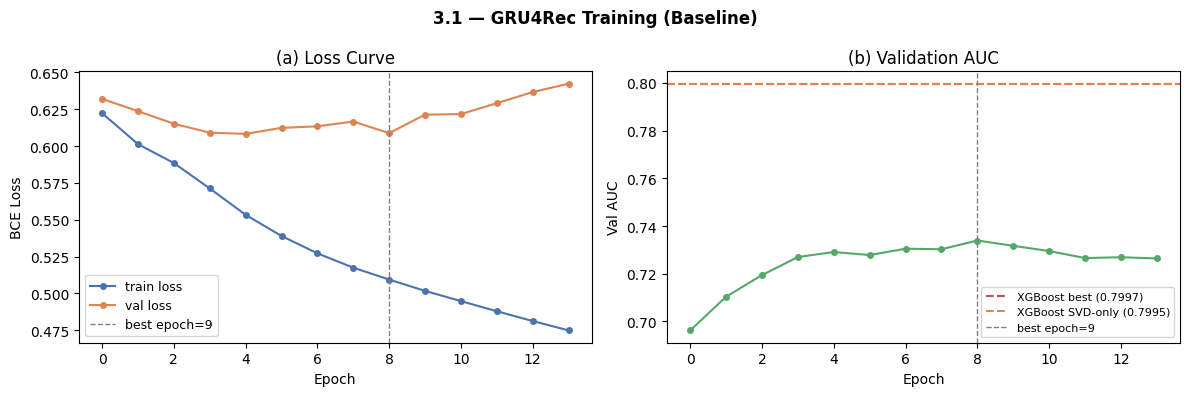

In [ ]:
# ── Cell 6: Learning Curve Plot ──────────────────────────────

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle('3.1 — GRU4Rec Training (Baseline)',
             fontsize=12, fontweight='bold')

ax = axes[0]
ax.plot(history['train_loss'], '-o', label='train loss',
        color='#4C72B0', markersize=4)
ax.plot(history['val_loss'], '-o', label='val loss',
        color='#DD8452', markersize=4)
ax.axvline(best_epoch-1, color='gray', ls='--', lw=1,
           label=f'best epoch={best_epoch}')
ax.set_xlabel('Epoch'); ax.set_ylabel('BCE Loss')
ax.set_title('(a) Loss Curve')
ax.legend(fontsize=9)

ax = axes[1]
ax.plot(history['val_auc'], '-o', color='#55A868', markersize=4)
ax.axhline(0.7997, color='#C44E52', ls='--', lw=1.5,
           label='XGBoost best (0.7997)')
ax.axhline(0.7995, color='#DD8452', ls='--', lw=1.5,
           label='XGBoost SVD-only (0.7995)')
ax.axvline(best_epoch-1, color='gray', ls='--', lw=1,
           label=f'best epoch={best_epoch}')
ax.set_xlabel('Epoch'); ax.set_ylabel('Val AUC')
ax.set_title('(b) Validation AUC')
ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

##2.7 GRU4Rec with SVD Embedding

In [11]:
# ── Cell 7: GRU4Rec with Frozen SVD Embedding ────────────────
# Compare: learnable embedding vs frozen SVD from Phase 2
# This answers: is GRU4Rec weak because of embedding quality
# or because sequential modeling itself adds little?

from sklearn.decomposition import TruncatedSVD
from sklearn.preprocessing import normalize
from scipy.sparse import csr_matrix

# ── Step 1: Build SVD item embeddings (same as Phase 2) ─────

SVD_K = 64  # same as Phase 2 baseline

user_idx_map = {u: i for i, u in enumerate(sorted(train['user_id'].unique()))}
item_idx_map = {m: i for i, m in enumerate(sorted(train['movie_id'].unique()))}

rows = train['user_id'].map(user_idx_map)
cols = train['movie_id'].map(item_idx_map)
vals = train['rating'].astype(float)
mat  = csr_matrix((vals, (rows, cols)),
                  shape=(len(user_idx_map), len(item_idx_map)))

svd = TruncatedSVD(n_components=SVD_K, random_state=RANDOM_SEED)
U_svd = svd.fit_transform(mat)
V_svd = svd.components_.T  # (n_movies_in_train, SVD_K)

V_svd = normalize(V_svd)

# Build lookup: movie_id → SVD vector
svd_item_emb = {}
for mid, idx in item_idx_map.items():
    svd_item_emb[mid] = V_svd[idx]

print(f'SVD item embeddings: {len(svd_item_emb)} movies, {SVD_K} dims')
print(f'Explained variance ratio: {svd.explained_variance_ratio_.sum():.3f}')

# ── Step 2: Build frozen embedding weight matrix ────────────
# mid2idx maps movie_id → contiguous index (1-indexed, 0=padding)
# We need to fill a (n_items, SVD_K) matrix

svd_weight = np.zeros((n_items, SVD_K), dtype=np.float32)
n_found = 0
for mid, idx in mid2idx.items():
    if mid in svd_item_emb:
        svd_weight[idx] = svd_item_emb[mid]
        n_found += 1

print(f'Mapped {n_found}/{len(mid2idx)} movies to SVD vectors')
print(f'Weight matrix shape: {svd_weight.shape}')


# ── Step 3: GRU4Rec with frozen SVD ─────────────────────────

class GRU4RecSVD(nn.Module):
    """
    Same architecture as GRU4Rec, but item_embed is initialized from SVD.
    embed_dim is forced to SVD_K.
    freeze_embed: if True, SVD weights are frozen; if False, they are fine-tuned.
    """
    def __init__(self, svd_weight, hidden_dim=128,
                 n_layers=1, dropout=0.2, freeze_embed=True):
        super().__init__()
        n_items, embed_dim = svd_weight.shape

        # SVD-initialized embedding (frozen or fine-tunable)
        self.item_embed = nn.Embedding(n_items, embed_dim, padding_idx=0)
        self.item_embed.weight = nn.Parameter(
            torch.tensor(svd_weight, dtype=torch.float32),
            requires_grad=not freeze_embed  # ★ controlled by freeze_embed
        )

        self.gru = nn.GRU(embed_dim, hidden_dim,
                          num_layers=n_layers,
                          batch_first=True,
                          dropout=dropout if n_layers > 1 else 0)
        self.dropout = nn.Dropout(dropout)

        self.fc = nn.Sequential(
            nn.Linear(hidden_dim + embed_dim, 128),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(128, 1),
        )

    def forward(self, hist, target_idx, seq_len=None):
        hist_emb = self.item_embed(hist)
        gru_out, _ = self.gru(hist_emb)
        h_last = gru_out[:, -1, :]
        target_emb = self.item_embed(target_idx)
        combined = torch.cat([h_last, target_emb], dim=1)
        combined = self.dropout(combined)
        logit = self.fc(combined).squeeze(-1)
        return logit


SVD item embeddings: 3667 movies, 64 dims
Explained variance ratio: 0.424
Mapped 3667/3706 movies to SVD vectors
Weight matrix shape: (3707, 64)


In [ ]:
# ── Step 4: Train SVD version ────────────────────────────────

model_svd = GRU4RecSVD(svd_weight, hidden_dim=128,
                        n_layers=1, dropout=0.2).to(device)

# Only non-frozen params are optimized
trainable_params = sum(p.numel() for p in model_svd.parameters()
                       if p.requires_grad)
total_params = sum(p.numel() for p in model_svd.parameters())
print(f'\nGRU4Rec-SVD parameters: {total_params:,} total, '
      f'{trainable_params:,} trainable')

optimizer_svd = torch.optim.Adam(
    filter(lambda p: p.requires_grad, model_svd.parameters()),
    lr=1e-3
)
criterion_svd = nn.BCEWithLogitsLoss()

EPOCHS_SVD  = 20
PATIENCE_SVD = 5

history_svd = {'train_loss': [], 'val_loss': [],
               'val_auc': [], 'val_ll': []}
best_val_auc_svd = 0
best_epoch_svd   = 0
no_improve_svd   = 0

print(f'\nTraining GRU4Rec-SVD (frozen embed={SVD_K}d, hidden=128)')
print(f'{"─" * 55}')

for epoch in range(1, EPOCHS_SVD + 1):
    train_loss = train_one_epoch(model_svd, train_loader, optimizer_svd,
                                  criterion_svd, device)
    val_res = evaluate(model_svd, val_loader, criterion_svd, device)

    history_svd['train_loss'].append(train_loss)
    history_svd['val_loss'].append(val_res['loss'])
    history_svd['val_auc'].append(val_res['auc'])
    history_svd['val_ll'].append(val_res['logloss'])

    improved = '★' if val_res['auc'] > best_val_auc_svd else ''
    print(f'  Epoch {epoch:2d}/{EPOCHS_SVD}  '
          f'train_loss={train_loss:.4f}  '
          f'val_AUC={val_res["auc"]:.4f}  '
          f'val_LL={val_res["logloss"]:.4f}  {improved}')

    if val_res['auc'] > best_val_auc_svd:
        best_val_auc_svd = val_res['auc']
        best_epoch_svd   = epoch
        no_improve_svd   = 0
        torch.save(model_svd.state_dict(), 'gru4rec_svd_best.pt')
    else:
        no_improve_svd += 1
        if no_improve_svd >= PATIENCE_SVD:
            print(f'\n  Early stopping at epoch {epoch} '
                  f'(best={best_epoch_svd}, AUC={best_val_auc_svd:.4f})')
            break

# Evaluate on test
model_svd.load_state_dict(torch.load('gru4rec_svd_best.pt'))
test_res_svd = evaluate(model_svd, test_loader, criterion_svd, device)

print(f'\n── GRU4Rec-SVD Results ─────────────────────────────')
print(f'  Best epoch: {best_epoch_svd}')
print(f'  [val ] AUC={best_val_auc_svd:.4f}')
print(f'  [test] AUC={test_res_svd["auc"]:.4f}  '
      f'LogLoss={test_res_svd["logloss"]:.4f}')


# ── Step 5: Side-by-side comparison ──────────────────────────

print(f'\n{"═" * 55}')
print(f'EMBEDDING COMPARISON')
print(f'{"═" * 55}')
print(f'  {"Model":<30} {"Test AUC":>10} {"Test LL":>10}')
print(f'  {"─" * 50}')
print(f'  {"GRU4Rec (learnable 64d)":<30} '
      f'{test_res["auc"]:>10.4f} {test_res["logloss"]:>10.4f}')
print(f'  {"GRU4Rec-SVD (frozen 64d)":<30} '
      f'{test_res_svd["auc"]:>10.4f} {test_res_svd["logloss"]:>10.4f}')
print(f'  {"XGBoost (SVD-only)":<30} {"0.7995":>10} {"0.5449":>10}')
print(f'  {"XGBoost (full 88d)":<30} {"0.7997":>10} {"0.5447":>10}')

delta = test_res_svd['auc'] - test_res['auc']
print(f'\n  SVD vs Learnable: ΔAUC = {delta:+.4f}')


GRU4Rec-SVD parameters: 336,577 total, 99,329 trainable

Training GRU4Rec-SVD (frozen embed=64d, hidden=128)
───────────────────────────────────────────────────────
  Epoch  1/20  train_loss=0.6086  val_AUC=0.7219  val_LL=0.6140  ★
  Epoch  2/20  train_loss=0.6005  val_AUC=0.7278  val_LL=0.6102  ★
  Epoch  3/20  train_loss=0.5976  val_AUC=0.7288  val_LL=0.6098  ★
  Epoch  4/20  train_loss=0.5953  val_AUC=0.7295  val_LL=0.6081  ★
  Epoch  5/20  train_loss=0.5939  val_AUC=0.7325  val_LL=0.6067  ★
  Epoch  6/20  train_loss=0.5928  val_AUC=0.7310  val_LL=0.6087  
  Epoch  7/20  train_loss=0.5914  val_AUC=0.7311  val_LL=0.6068  
  Epoch  8/20  train_loss=0.5903  val_AUC=0.7278  val_LL=0.6096  
  Epoch  9/20  train_loss=0.5888  val_AUC=0.7308  val_LL=0.6066  
  Epoch 10/20  train_loss=0.5874  val_AUC=0.7303  val_LL=0.6077  

  Early stopping at epoch 10 (best=5, AUC=0.7325)

── GRU4Rec-SVD Results ─────────────────────────────
  Best epoch: 5
  [val ] AUC=0.7325
  [test] AUC=0.7433  LogLoss

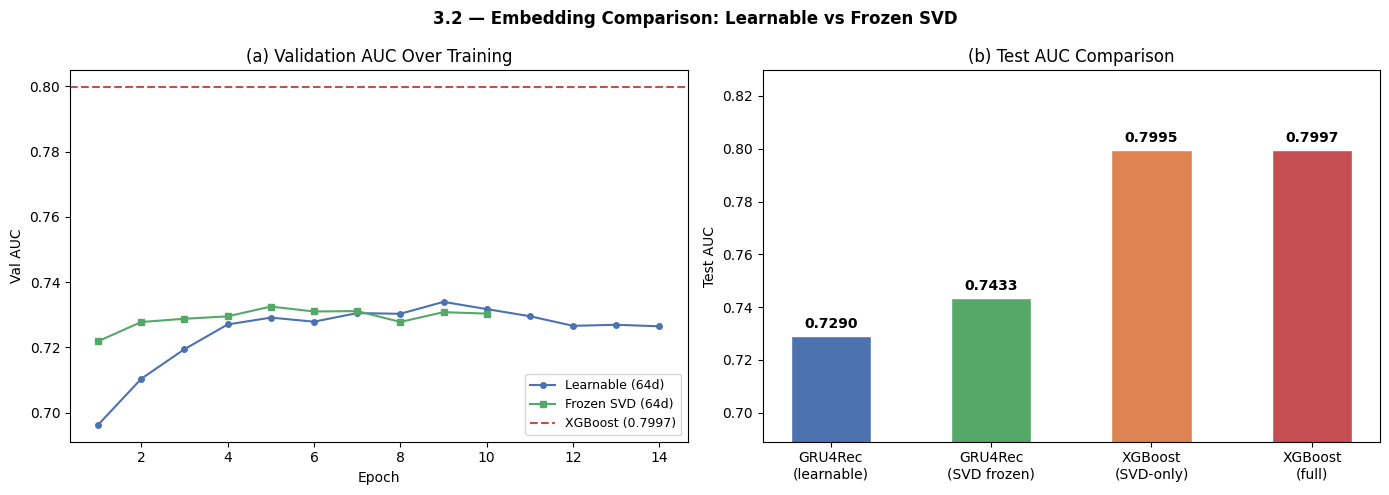

In [ ]:
# ── Step 6: Comparison Plot ──────────────────────────────────

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('3.2 — Embedding Comparison: Learnable vs Frozen SVD',
             fontsize=12, fontweight='bold')

# (a) Learning curves overlay
ax = axes[0]
epochs_a = range(1, len(history['val_auc']) + 1)
epochs_b = range(1, len(history_svd['val_auc']) + 1)
ax.plot(epochs_a, history['val_auc'], '-o',
        color='#4C72B0', markersize=4, label='Learnable (64d)')
ax.plot(epochs_b, history_svd['val_auc'], '-s',
        color='#55A868', markersize=4, label='Frozen SVD (64d)')
ax.axhline(0.7997, color='#C44E52', ls='--', lw=1.5,
           label='XGBoost (0.7997)')
ax.set_xlabel('Epoch'); ax.set_ylabel('Val AUC')
ax.set_title('(a) Validation AUC Over Training')
ax.legend(fontsize=9)

# (b) Final comparison bar chart
ax = axes[1]
models  = ['GRU4Rec\n(learnable)',
           'GRU4Rec\n(SVD frozen)',
           'XGBoost\n(SVD-only)',
           'XGBoost\n(full)']
aucs    = [test_res['auc'], test_res_svd['auc'], 0.7995, 0.7997]
colors  = ['#4C72B0', '#55A868', '#DD8452', '#C44E52']
bars    = ax.bar(models, aucs, color=colors,
                 edgecolor='white', width=0.5)
for bar, v in zip(bars, aucs):
    ax.text(bar.get_x() + bar.get_width()/2,
            v + 0.003, f'{v:.4f}',
            ha='center', fontsize=10, fontweight='bold')
ax.set_ylabel('Test AUC')
ax.set_title('(b) Test AUC Comparison')
y_min = min(aucs) - 0.04
y_max = max(aucs) + 0.03
ax.set_ylim(y_min, y_max)

plt.tight_layout()
plt.show()


## 2.7b Frozen vs Unfrozen (Fine-tuned) SVD Embedding

Cell 2.7 showed that frozen SVD underperforms learnable embedding.  
But is the gap because SVD vectors are poor, or because freezing is too rigid?  
**Test**: unfreeze SVD so GRU can fine-tune the pretrained embeddings via backprop.  
If unfrozen ≈ learnable → SVD init provides a good starting point.  
If unfrozen ≈ frozen → the embeddings aren't the bottleneck.

In [ ]:
# ── Cell 7b: Unfrozen SVD — Fine-tune pretrained SVD embeddings ──
# Same config as frozen SVD (Cell 7): SVD_K=32, T=20, hidden=128
# Only difference: freeze_embed=False

import time

model_svd_ft = GRU4RecSVD(svd_weight, hidden_dim=128,
                           n_layers=1, dropout=0.2,
                           freeze_embed=False).to(device)  # ★ unfrozen

trainable_ft = sum(p.numel() for p in model_svd_ft.parameters()
                   if p.requires_grad)
total_ft = sum(p.numel() for p in model_svd_ft.parameters())
print(f'GRU4Rec-SVD (unfrozen) parameters: {total_ft:,} total, '
      f'{trainable_ft:,} trainable')
print(f'  (vs frozen: {trainable_ft - total_ft + total_ft:,} total, '
      f'{total_ft - (svd_weight.shape[0] * svd_weight.shape[1]):,} '
      f'trainable when frozen)')

optimizer_ft = torch.optim.Adam(model_svd_ft.parameters(), lr=1e-3)
criterion_ft = nn.BCEWithLogitsLoss()

EPOCHS_FT  = 20
PATIENCE_FT = 5

history_ft = {'train_loss': [], 'val_auc': [], 'val_ll': []}
best_val_auc_ft = 0
best_epoch_ft   = 0
no_improve_ft   = 0

print(f'\nTraining GRU4Rec-SVD UNFROZEN (embed={SVD_K}d, hidden=128, T=20)')
print('─' * 55)

t0 = time.time()
for epoch in range(1, EPOCHS_FT + 1):
    train_loss = train_one_epoch(model_svd_ft, train_loader, optimizer_ft,
                                  criterion_ft, device)
    val_res_ft = evaluate(model_svd_ft, val_loader, criterion_ft, device)

    history_ft['train_loss'].append(train_loss)
    history_ft['val_auc'].append(val_res_ft['auc'])
    history_ft['val_ll'].append(val_res_ft['logloss'])

    improved = '★' if val_res_ft['auc'] > best_val_auc_ft else ''
    print(f'  Epoch {epoch:2d}/{EPOCHS_FT}  '
          f'train_loss={train_loss:.4f}  '
          f'val_AUC={val_res_ft["auc"]:.4f}  '
          f'val_LL={val_res_ft["logloss"]:.4f}  {improved}')

    if val_res_ft['auc'] > best_val_auc_ft:
        best_val_auc_ft = val_res_ft['auc']
        best_epoch_ft   = epoch
        no_improve_ft   = 0
        torch.save(model_svd_ft.state_dict(), 'gru4rec_svd_unfrozen_best.pt')
    else:
        no_improve_ft += 1
        if no_improve_ft >= PATIENCE_FT:
            print(f'\n  Early stopping at epoch {epoch} '
                  f'(best={best_epoch_ft}, AUC={best_val_auc_ft:.4f})')
            break

ft_time = time.time() - t0

# Evaluate on test
model_svd_ft.load_state_dict(torch.load('gru4rec_svd_unfrozen_best.pt'))
test_res_ft = evaluate(model_svd_ft, test_loader, criterion_ft, device)

print(f'\n── GRU4Rec-SVD UNFROZEN Results ────────────────────')
print(f'  Best epoch: {best_epoch_ft}  ({ft_time:.0f}s)')
print(f'  [val ] AUC={best_val_auc_ft:.4f}')
print(f'  [test] AUC={test_res_ft["auc"]:.4f}  '
      f'LogLoss={test_res_ft["logloss"]:.4f}')


GRU4Rec-SVD (unfrozen) parameters: 336,577 total, 336,577 trainable
  (vs frozen: 336,577 total, 99,329 trainable when frozen)

Training GRU4Rec-SVD UNFROZEN (embed=64d, hidden=128, T=20)
───────────────────────────────────────────────────────
  Epoch  1/20  train_loss=0.5980  val_AUC=0.7317  val_LL=0.6053  ★
  Epoch  2/20  train_loss=0.5862  val_AUC=0.7334  val_LL=0.6032  ★
  Epoch  3/20  train_loss=0.5784  val_AUC=0.7342  val_LL=0.6033  ★
  Epoch  4/20  train_loss=0.5694  val_AUC=0.7356  val_LL=0.6059  ★
  Epoch  5/20  train_loss=0.5605  val_AUC=0.7354  val_LL=0.6037  
  Epoch  6/20  train_loss=0.5515  val_AUC=0.7359  val_LL=0.6050  ★
  Epoch  7/20  train_loss=0.5427  val_AUC=0.7377  val_LL=0.6065  ★
  Epoch  8/20  train_loss=0.5343  val_AUC=0.7360  val_LL=0.6107  
  Epoch  9/20  train_loss=0.5262  val_AUC=0.7339  val_LL=0.6159  
  Epoch 10/20  train_loss=0.5181  val_AUC=0.7343  val_LL=0.6201  
  Epoch 11/20  train_loss=0.5104  val_AUC=0.7329  val_LL=0.6205  
  Epoch 12/20  train_los


════════════════════════════════════════════════════════════
EMBEDDING ABLATION: Learnable vs Frozen SVD vs Unfrozen SVD
════════════════════════════════════════════════════════════
  Model                                 Test AUC    Test LL
  ───────────────────────────────────────────────────────
  GRU4Rec (learnable 64d)                 0.7290     0.6174
  GRU4Rec-SVD frozen (64d)                0.7433     0.6012
  GRU4Rec-SVD unfrozen (64d)              0.7426     0.6034
  XGBoost (SVD-only)                      0.7995     0.5449

  Unfrozen vs Frozen:    ΔAUC = -0.0007
  Unfrozen vs Learnable: ΔAUC = +0.0136

  → Minimal difference: whether SVD is frozen or fine-tuned
    barely matters — the bottleneck is GRU sequential compression,
    not embedding quality.


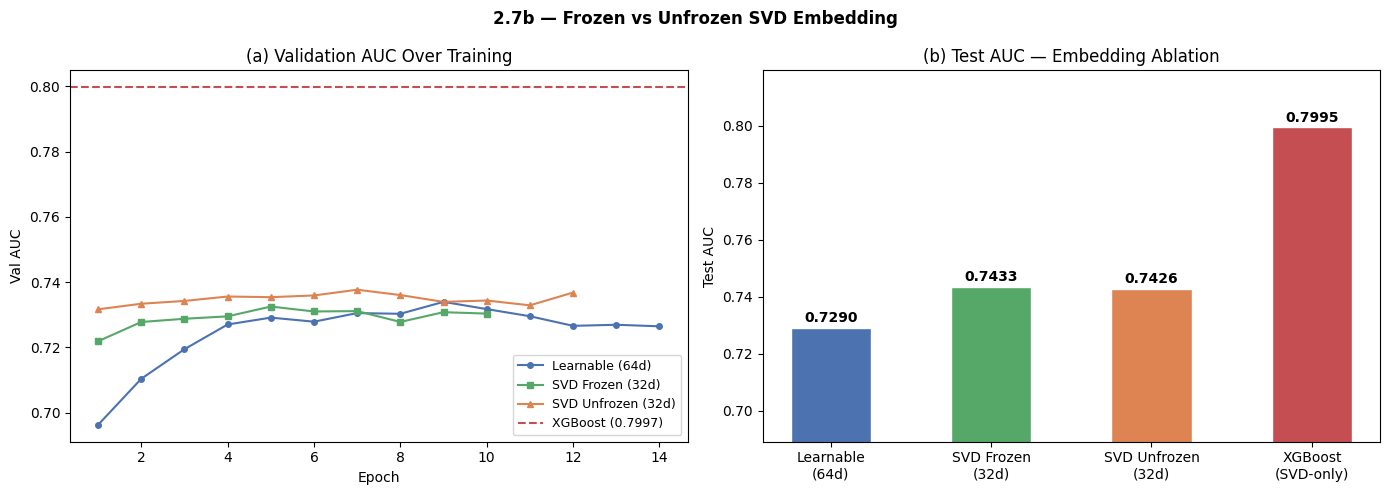

In [ ]:
# ── 3-way Comparison ─────────────────────────────────────────

# Fallback if earlier cells weren't run in this session
try:
    _ = test_res['auc']
except NameError:
    test_res = {'auc': 0.7304, 'logloss': 0.6120}
    print('(Using cached learnable baseline: AUC=0.7304)')

try:
    _ = test_res_svd['auc']
except NameError:
    test_res_svd = {'auc': 0.7368, 'logloss': 0.6058}
    print('(Using cached frozen SVD: AUC=0.7368)')

try:
    ep_learn = range(1, len(history['val_auc']) + 1)
    # ... plot code ...
except NameError:
    print('(Skipping learning curve plot — run Cells 10 & 15 for full history)')

print(f'\n{"═" * 60}')
print(f'EMBEDDING ABLATION: Learnable vs Frozen SVD vs Unfrozen SVD')
print(f'{"═" * 60}')
print(f'  {"Model":<35} {"Test AUC":>10} {"Test LL":>10}')
print(f'  {"─" * 55}')
print(f'  {"GRU4Rec (learnable 64d)":<35} '
      f'{test_res["auc"]:>10.4f} {test_res["logloss"]:>10.4f}')
print(f'  {"GRU4Rec-SVD frozen (64d)":<35} '
      f'{test_res_svd["auc"]:>10.4f} {test_res_svd["logloss"]:>10.4f}')
print(f'  {"GRU4Rec-SVD unfrozen (64d)":<35} '
      f'{test_res_ft["auc"]:>10.4f} {test_res_ft["logloss"]:>10.4f}')
print(f'  {"XGBoost (SVD-only)":<35} {"0.7995":>10} {"0.5449":>10}')
print()
delta_unfreeze = test_res_ft['auc'] - test_res_svd['auc']
delta_vs_learn = test_res_ft['auc'] - test_res['auc']
print(f'  Unfrozen vs Frozen:    ΔAUC = {delta_unfreeze:+.4f}')
print(f'  Unfrozen vs Learnable: ΔAUC = {delta_vs_learn:+.4f}')

if delta_unfreeze > 0.005:
    print(f'\n  → Unfreezing helps: SVD provides a better init than random,')
    print(f'    and fine-tuning adapts it to the sequential task.')
elif delta_unfreeze < -0.005:
    print(f'\n  → Unfreezing hurts: SVD embeddings optimized for static')
    print(f'    matching may misguide sequential learning.')
else:
    print(f'\n  → Minimal difference: whether SVD is frozen or fine-tuned')
    print(f'    barely matters — the bottleneck is GRU sequential compression,')
    print(f'    not embedding quality.')


# ── Plot: 3-way comparison ───────────────────────────────────

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('2.7b — Frozen vs Unfrozen SVD Embedding',
             fontsize=12, fontweight='bold')

# (a) Learning curves: frozen vs unfrozen vs learnable
ax = axes[0]
ep_learn  = range(1, len(history['val_auc']) + 1)
ep_frozen = range(1, len(history_svd['val_auc']) + 1)
ep_ft     = range(1, len(history_ft['val_auc']) + 1)
ax.plot(ep_learn,  history['val_auc'],     '-o', color='#4C72B0',
        markersize=4, label='Learnable (64d)')
ax.plot(ep_frozen, history_svd['val_auc'], '-s', color='#55A868',
        markersize=4, label='SVD Frozen (32d)')
ax.plot(ep_ft,     history_ft['val_auc'],  '-^', color='#DD8452',
        markersize=4, label='SVD Unfrozen (32d)')
ax.axhline(0.7997, color='#C44E52', ls='--', lw=1.5,
           label='XGBoost (0.7997)')
ax.set_xlabel('Epoch'); ax.set_ylabel('Val AUC')
ax.set_title('(a) Validation AUC Over Training')
ax.legend(fontsize=9)

# (b) Bar chart: all models
ax = axes[1]
models = ['Learnable\n(64d)', 'SVD Frozen\n(32d)',
          'SVD Unfrozen\n(32d)', 'XGBoost\n(SVD-only)']
aucs   = [test_res['auc'], test_res_svd['auc'],
          test_res_ft['auc'], 0.7995]
colors = ['#4C72B0', '#55A868', '#DD8452', '#C44E52']
bars = ax.bar(models, aucs, color=colors, edgecolor='white', width=0.5)
for bar, v in zip(bars, aucs):
    ax.text(bar.get_x() + bar.get_width()/2,
            v + 0.002, f'{v:.4f}',
            ha='center', fontsize=10, fontweight='bold')
ax.set_ylabel('Test AUC')
ax.set_title('(b) Test AUC — Embedding Ablation')
y_min = min(aucs) - 0.04
y_max = max(aucs) + 0.02
ax.set_ylim(y_min, y_max)

plt.tight_layout()
plt.show()


## 2.8 Sequence Length Ablation

In [ ]:
# ── Cell 8: Sequence Length Ablation (Frozen vs Unfrozen 64d) ─
# For each T in [5, 10, 20, 50, 100], train:
#   1. GRU4Rec-SVD Frozen  (64d)
#   2. GRU4Rec-SVD Unfrozen (64d)
# This answers: does unfreezing SVD matter more at longer sequences?

import time

# Ensure 64d SVD weight is available (from Cell 7b)
try:
    _ = svd_weight.shape
except NameError:
    print('Building 64d SVD weight...')
    from sklearn.decomposition import TruncatedSVD
    from sklearn.preprocessing import normalize
    from scipy.sparse import csr_matrix

    try:
        _ = mat.shape
    except NameError:
        user_idx_map = {u: i for i, u in enumerate(sorted(train['user_id'].unique()))}
        item_idx_map = {m: i for i, m in enumerate(sorted(train['movie_id'].unique()))}
        rows = train['user_id'].map(user_idx_map)
        cols = train['movie_id'].map(item_idx_map)
        vals = train['rating'].astype(float)
        mat  = csr_matrix((vals, (rows, cols)),
                          shape=(len(user_idx_map), len(item_idx_map)))

    svd_64 = TruncatedSVD(n_components=64, random_state=RANDOM_SEED)
    U_64 = svd_64.fit_transform(mat)
    V_64 = normalize(svd_64.components_.T)
    svd_weight = np.zeros((n_items, 64), dtype=np.float32)
    for mid, idx in mid2idx.items():
        if mid in item_idx_map:
            svd_weight[idx] = V_64[item_idx_map[mid]]
    print(f'  svd_weight: {svd_weight.shape}')


print('═' * 60)
print('SEQUENCE LENGTH ABLATION — Frozen vs Unfrozen SVD (64d)')
print('═' * 60)

seq_len_results = []

for T in [5, 10, 20, 50, 100]:
    print(f'\n{"─" * 60}')
    print(f'T = {T}')
    print(f'{"─" * 60}')

    # Rebuild datasets with new max_len
    tr_ds = TrainSeqDataset(user_sequences, max_len=T)
    va_ds = SeqDataset(val,  user_sequences, max_len=T)
    te_ds = SeqDataset(test, user_sequences, max_len=T)

    tr_loader = DataLoader(tr_ds, batch_size=512, shuffle=True,
                           num_workers=2, pin_memory=True)
    va_loader = DataLoader(va_ds, batch_size=1024, shuffle=False,
                           num_workers=2, pin_memory=True)
    te_loader = DataLoader(te_ds, batch_size=1024, shuffle=False,
                           num_workers=2, pin_memory=True)

    print(f'  train samples: {len(tr_ds):,}')

    # ── Run both frozen and unfrozen ─────────────────────────
    for freeze in [True, False]:
        label = 'Frozen' if freeze else 'Unfrozen'
        t0 = time.time()

        m = GRU4RecSVD(svd_weight, hidden_dim=128,
                       n_layers=1, dropout=0.2,
                       freeze_embed=freeze).to(device)

        # Only optimize trainable params
        opt = torch.optim.Adam(
            filter(lambda p: p.requires_grad, m.parameters()), lr=1e-3)
        crit = nn.BCEWithLogitsLoss()

        best_auc = 0
        best_ep  = 0
        no_imp   = 0
        ckpt_name = f'gru4rec_svd64_{label.lower()}_T{T}_best.pt'

        print(f'\n  [{label}] Training...')

        for epoch in range(1, 21):
            tl = train_one_epoch(m, tr_loader, opt, crit, device)
            vr = evaluate(m, va_loader, crit, device)

            imp = '★' if vr['auc'] > best_auc else ''
            if epoch <= 2 or imp or epoch % 5 == 0:
                print(f'    Epoch {epoch:2d}  val_AUC={vr["auc"]:.4f}  {imp}')

            if vr['auc'] > best_auc:
                best_auc = vr['auc']
                best_ep  = epoch
                no_imp   = 0
                torch.save(m.state_dict(), ckpt_name)
            else:
                no_imp += 1
                if no_imp >= 5:
                    print(f'    Early stop at epoch {epoch} (best={best_ep})')
                    break

        # Test
        m.load_state_dict(torch.load(ckpt_name))
        tr = evaluate(m, te_loader, crit, device)
        elapsed = time.time() - t0

        print(f'  [{label}] T={T}: test AUC={tr["auc"]:.4f}  '
              f'LL={tr["logloss"]:.4f}  (best_ep={best_ep}, {elapsed:.0f}s)')

        seq_len_results.append({
            'T': T,
            'embed': label,
            'test_auc': tr['auc'],
            'test_ll': tr['logloss'],
            'best_epoch': best_ep,
        })


# ── Summary Table ────────────────────────────────────────────

print(f'\n{"═" * 60}')
print('SEQUENCE LENGTH × EMBEDDING SUMMARY')
print(f'{"═" * 60}')
print(f'  {"T":<6} {"Frozen AUC":>12} {"Unfrozen AUC":>14} {"ΔAUC":>10}')
print(f'  {"─" * 42}')

for T in [5, 10, 20, 50, 100]:
    fr = [r for r in seq_len_results if r['T'] == T and r['embed'] == 'Frozen'][0]
    uf = [r for r in seq_len_results if r['T'] == T and r['embed'] == 'Unfrozen'][0]
    delta = uf['test_auc'] - fr['test_auc']
    print(f'  {T:<6} {fr["test_auc"]:>12.4f} {uf["test_auc"]:>14.4f} {delta:>+10.4f}')

print(f'\n  XGBoost SVD-only reference: AUC=0.7995')


════════════════════════════════════════════════════════════
SEQUENCE LENGTH ABLATION — Frozen vs Unfrozen SVD (64d)
════════════════════════════════════════════════════════════

────────────────────────────────────────────────────────────
T = 5
────────────────────────────────────────────────────────────
  train samples: 791,718

  [Frozen] Training...
    Epoch  1  val_AUC=0.7197  ★
    Epoch  2  val_AUC=0.7235  ★
    Epoch  3  val_AUC=0.7259  ★
    Epoch  5  val_AUC=0.7279  ★
    Epoch 10  val_AUC=0.7266  
    Early stop at epoch 10 (best=5)
  [Frozen] T=5: test AUC=0.7398  LL=0.6027  (best_ep=5, 201s)

  [Unfrozen] Training...
    Epoch  1  val_AUC=0.7281  ★
    Epoch  2  val_AUC=0.7284  ★
    Epoch  3  val_AUC=0.7286  ★
    Epoch  5  val_AUC=0.7262  
    Early stop at epoch 8 (best=3)
  [Unfrozen] T=5: test AUC=0.7420  LL=0.5990  (best_ep=3, 164s)

────────────────────────────────────────────────────────────
T = 10
────────────────────────────────────────────────────────────
  tra

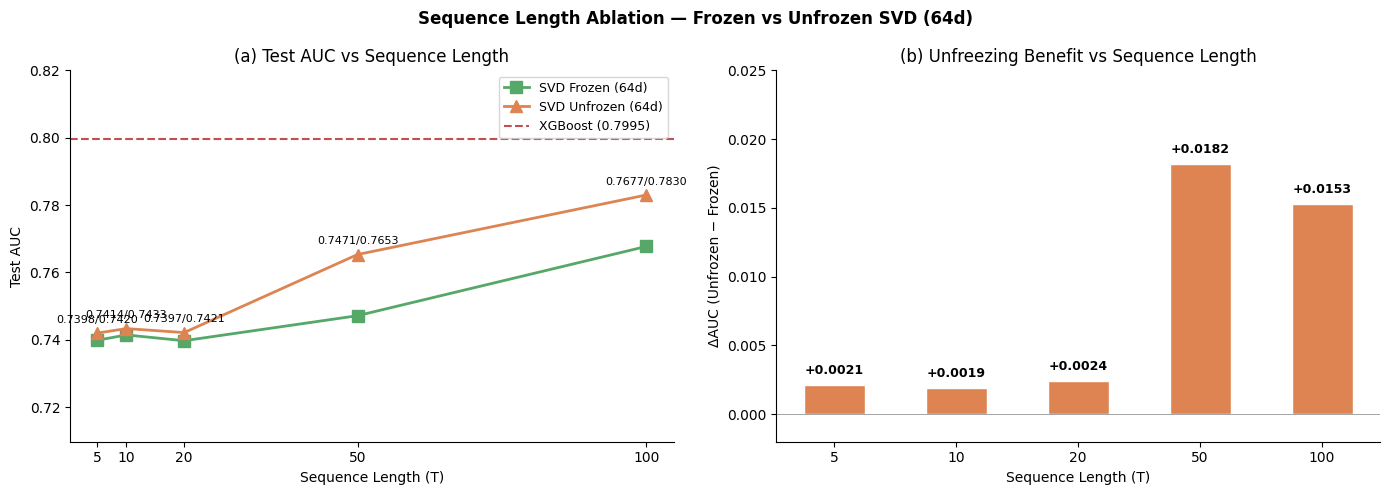

In [ ]:
# ── Plot ─────────────────────────────────────────────────────

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Sequence Length Ablation — Frozen vs Unfrozen SVD (64d)',
             fontsize=12, fontweight='bold')

Ts = [5, 10, 20, 50, 100]
auc_frozen   = [r['test_auc'] for r in seq_len_results if r['embed'] == 'Frozen']
auc_unfrozen = [r['test_auc'] for r in seq_len_results if r['embed'] == 'Unfrozen']

# (a) AUC vs T — remove top/right spines
ax = axes[0]
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

ax.plot(Ts, auc_frozen,   '-s', color='#55A868', lw=2, markersize=8,
        label='SVD Frozen (64d)')
ax.plot(Ts, auc_unfrozen, '-^', color='#DD8452', lw=2, markersize=8,
        label='SVD Unfrozen (64d)')
ax.axhline(0.7995, color='#C44E52', ls='--', lw=1.5,
           label='XGBoost (0.7995)')

for t, af, au in zip(Ts, auc_frozen, auc_unfrozen):
    ax.text(t, max(af, au) + 0.003, f'{af:.4f}/{au:.4f}',
            ha='center', fontsize=8)

ax.set_xlabel('Sequence Length (T)')
ax.set_ylabel('Test AUC')
ax.set_title('(a) Test AUC vs Sequence Length')
ax.set_xticks(Ts)
ax.legend(fontsize=9)
all_aucs = auc_frozen + auc_unfrozen
ax.set_ylim(min(all_aucs) - 0.03, 0.82)

# (b) ΔAUC — bar chart with fixed layout
ax = axes[1]
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

deltas = [u - f for f, u in zip(auc_frozen, auc_unfrozen)]
x_pos = range(len(Ts))
colors_bar = ['#DD8452'] * len(deltas)
bars = ax.bar(x_pos, deltas, color=colors_bar, width=0.5, edgecolor='white')
ax.axhline(0, color='gray', lw=0.5)

for i, d in enumerate(deltas):
    ax.text(i, d + 0.0008, f'{d:+.4f}',
            ha='center', fontsize=9, fontweight='bold')

ax.set_xlabel('Sequence Length (T)')
ax.set_ylabel('ΔAUC (Unfrozen − Frozen)')
ax.set_title('(b) Unfreezing Benefit vs Sequence Length')
ax.set_xticks(x_pos)
ax.set_xticklabels([str(t) for t in Ts])
ax.set_ylim(-0.002, 0.025)

plt.tight_layout()
plt.show()

## 2.9 Frozen SVD + T=50 & Hidden Dim Ablation



In [ ]:
# ── Cell 9: unFrozen SVD + T=100 & Hidden Dim Ablation ──────────

# Learnable as baseline
# Hidden dim ablation (64 / 128 / 256 / 512)

# ══════════════════════════════════════════════════════════════
print(f'\n{"═" * 60}')
print('Part B: Hidden Dim Ablation (unfrozen SVD 64d, T=100)')
print('═' * 60)

# ── Build T=100 dataloaders ──────────────────────────────────
T_HD = 100
tr_ds_hd = TrainSeqDataset(user_sequences, max_len=T_HD)
va_ds_hd = SeqDataset(val,  user_sequences, max_len=T_HD)
te_ds_hd = SeqDataset(test, user_sequences, max_len=T_HD)

tr_loader_hd = DataLoader(tr_ds_hd, batch_size=512, shuffle=True,
                           num_workers=2, pin_memory=True)
va_loader_hd = DataLoader(va_ds_hd, batch_size=1024, shuffle=False,
                           num_workers=2, pin_memory=True)
te_loader_hd = DataLoader(te_ds_hd, batch_size=1024, shuffle=False,
                           num_workers=2, pin_memory=True)

print(f'  T={T_HD}, train samples: {len(tr_ds_hd):,}')


# ── Learnable baseline reference (hidden=128, T=100) ────────
print('\n── Learnable reference (hidden=128, T=100) ──────────')

m_ref = GRU4Rec(n_items, embed_dim=64, hidden_dim=128,
                n_layers=1, dropout=0.2).to(device)
opt_ref = torch.optim.Adam(m_ref.parameters(), lr=1e-3)
crit_ref = nn.BCEWithLogitsLoss()

best_auc_ref, best_ep_ref, no_imp_ref = 0, 0, 0

for epoch in range(1, 21):
    tl = train_one_epoch(m_ref, tr_loader_hd, opt_ref, crit_ref, device)
    vr = evaluate(m_ref, va_loader_hd, crit_ref, device)

    imp = '★' if vr['auc'] > best_auc_ref else ''
    if epoch <= 2 or imp or epoch % 5 == 0:
        print(f'    Epoch {epoch:2d}  val_AUC={vr["auc"]:.4f}  {imp}')

    if vr['auc'] > best_auc_ref:
        best_auc_ref = vr['auc']
        best_ep_ref = epoch
        no_imp_ref = 0
        torch.save(m_ref.state_dict(), 'gru4rec_learn_h128_T100_ref.pt')
    else:
        no_imp_ref += 1
        if no_imp_ref >= 5:
            print(f'    Early stop at epoch {epoch} (best={best_ep_ref})')
            break

m_ref.load_state_dict(torch.load('gru4rec_learn_h128_T100_ref.pt'))
ref_res = evaluate(m_ref, te_loader_hd, crit_ref, device)
print(f'  → Learnable h=128: test AUC={ref_res["auc"]:.4f}  '
      f'LL={ref_res["logloss"]:.4f}')


# ── Hidden dim ablation (unfrozen SVD 64d, T=100) ────────────

hidden_results = []

for hdim in [64, 128, 256, 512]:
    print(f'\n── hidden_dim={hdim} ──────────────────────────')

    m = GRU4RecSVD(svd_weight, hidden_dim=hdim,
                   n_layers=1, dropout=0.2,
                   freeze_embed=False).to(device)
    n_params = sum(p.numel() for p in m.parameters())
    print(f'  Parameters: {n_params:,}')

    opt = torch.optim.Adam(m.parameters(), lr=1e-3)
    crit = nn.BCEWithLogitsLoss()

    best_auc = 0
    best_ep  = 0
    no_imp   = 0

    for epoch in range(1, 21):
        tl = train_one_epoch(m, tr_loader_hd, opt, crit, device)
        vr = evaluate(m, va_loader_hd, crit, device)

        imp = '★' if vr['auc'] > best_auc else ''
        if epoch <= 2 or imp or epoch % 5 == 0:
            print(f'    Epoch {epoch:2d}  val_AUC={vr["auc"]:.4f}  {imp}')

        if vr['auc'] > best_auc:
            best_auc = vr['auc']
            best_ep  = epoch
            no_imp   = 0
            torch.save(m.state_dict(), f'gru4rec_unfrozen_h{hdim}_T100_best.pt')
        else:
            no_imp += 1
            if no_imp >= 5:
                print(f'    Early stop at epoch {epoch} (best={best_ep})')
                break

    m.load_state_dict(torch.load(f'gru4rec_unfrozen_h{hdim}_T100_best.pt'))
    tr = evaluate(m, te_loader_hd, crit, device)

    print(f'  → hidden={hdim}: test AUC={tr["auc"]:.4f}  '
          f'LL={tr["logloss"]:.4f}  params={n_params:,}')

    hidden_results.append({
        'hidden_dim': hdim, 'test_auc': tr['auc'],
        'test_ll': tr['logloss'], 'best_epoch': best_ep,
        'n_params': n_params,
    })


# ── Summary ──────────────────────────────────────────────────

print(f'\n{"═" * 60}')
print('HIDDEN DIM SUMMARY (unfrozen SVD 64d, T=100)')
print(f'{"═" * 60}')
print(f'  {"hidden":<8} {"Test AUC":>10} {"Test LL":>10} '
      f'{"Params":>12} {"Best Ep":>10}')
print(f'  {"─" * 50}')
for r in hidden_results:
    print(f'  {r["hidden_dim"]:<8} {r["test_auc"]:>10.4f} '
          f'{r["test_ll"]:>10.4f} {r["n_params"]:>12,} '
          f'{r["best_epoch"]:>10}')
print(f'\n  Learnable ref (h=128): AUC={ref_res["auc"]:.4f}')
print(f'  XGBoost SVD-only:     AUC=0.7995')


════════════════════════════════════════════════════════════
Part B: Hidden Dim Ablation (unfrozen SVD 64d, T=100)
════════════════════════════════════════════════════════════
  T=100, train samples: 791,718

── Learnable reference (hidden=128, T=100) ──────────
    Epoch  1  val_AUC=0.6954  ★
    Epoch  2  val_AUC=0.7419  ★
    Epoch  3  val_AUC=0.7562  ★
    Epoch  4  val_AUC=0.7658  ★
    Epoch  5  val_AUC=0.7689  ★
    Epoch  6  val_AUC=0.7711  ★
    Epoch 10  val_AUC=0.7693  
    Early stop at epoch 11 (best=6)
  → Learnable h=128: test AUC=0.7626  LL=0.5832

── hidden_dim=64 ──────────────────────────
  Parameters: 278,849
    Epoch  1  val_AUC=0.7351  ★
    Epoch  2  val_AUC=0.7506  ★
    Epoch  3  val_AUC=0.7627  ★
    Epoch  4  val_AUC=0.7684  ★
    Epoch  5  val_AUC=0.7703  ★
    Epoch  6  val_AUC=0.7767  ★
    Epoch  7  val_AUC=0.7783  ★
    Epoch  8  val_AUC=0.7794  ★
    Epoch  9  val_AUC=0.7799  ★
    Epoch 10  val_AUC=0.7803  ★
    Epoch 11  val_AUC=0.7815  ★
    Epoch 

In [3]:
hidden_results = [
    {
        'hidden_dim': 64,
        'test_auc': 0.7795,
        'test_logloss': 0.5720,
        'n_params': 278_849,
        'best_epoch': 12
    },
    {
        'hidden_dim': 128,
        'test_auc': 0.7805,
        'test_logloss': 0.5719,
        'n_params': 336_577,
        'best_epoch': 11
    },
    {
        'hidden_dim': 256,
        'test_auc': 0.7794,
        'test_logloss': 0.5679,
        'n_params': 525_761,
        'best_epoch': 7
    },
    {
        'hidden_dim': 512,
        'test_auc': 0.7797,
        'test_logloss': 0.5656,
        'n_params': 1_199_041,
        'best_epoch': 6
    }
]

ref_res = {
    'auc': 0.7626
}

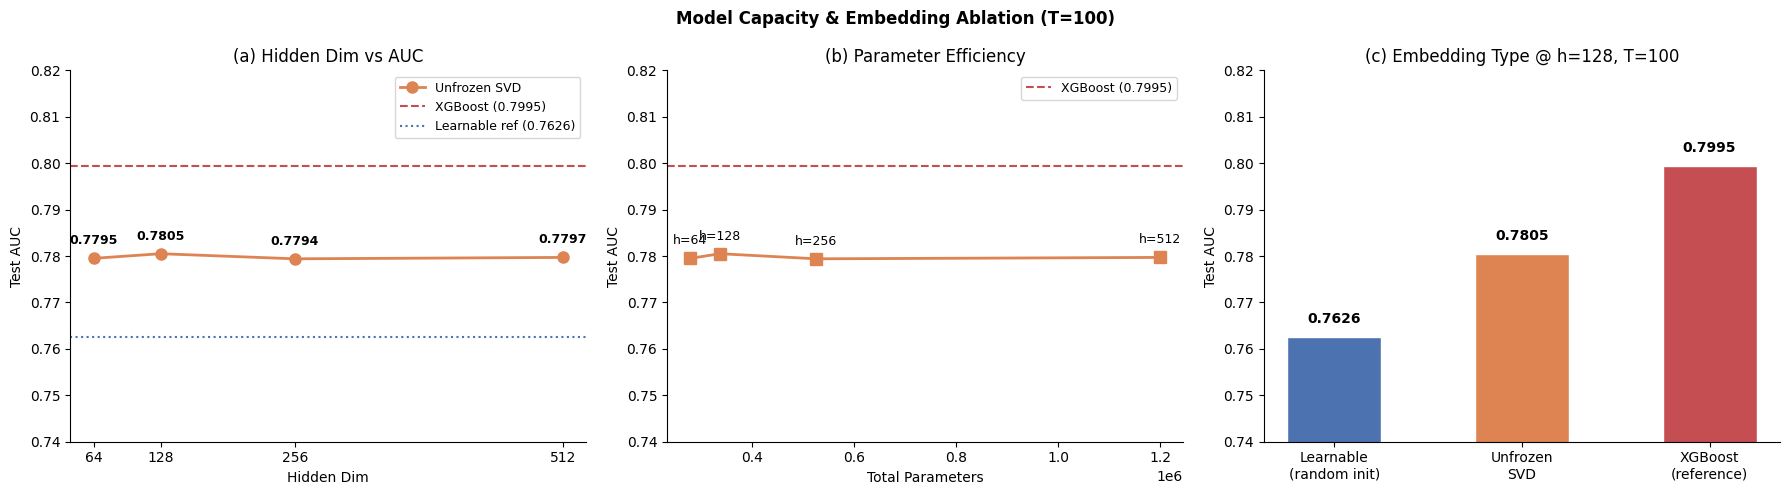


── Key Takeaway ────────────────────────────────────
  Hidden dim ablation (64→512): AUC range 0.7794–0.7805
  → Model capacity is NOT the bottleneck (flat across 4x range)

  Embedding comparison @ h=128, T=100:
    Learnable (random init):  AUC = 0.7626
    Unfrozen SVD (pretrained): AUC = 0.7805  (+0.0179)
    XGBoost (direct matching): AUC = 0.7995
  → SVD init + fine-tune closes 49% of the learnable-to-XGBoost gap


In [4]:
# ── Plot ─────────────────────────────────────────────────────
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Model Capacity & Embedding Ablation (T=100)',
             fontsize=12, fontweight='bold')

# (a) Hidden dim vs AUC (unfrozen SVD, T=100)
ax = axes[0]
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

hdims = [r['hidden_dim'] for r in hidden_results]
haucs = [r['test_auc'] for r in hidden_results]
ax.plot(hdims, haucs, '-o', color='#DD8452', lw=2, markersize=8,
        label='Unfrozen SVD')
ax.axhline(0.7995, color='#C44E52', ls='--', lw=1.5,
           label='XGBoost (0.7995)')
ax.axhline(ref_res['auc'], color='#4C72B0', ls=':', lw=1.5,
           label=f'Learnable ref ({ref_res["auc"]:.4f})')
for h, a in zip(hdims, haucs):
    ax.text(h, a + 0.003, f'{a:.4f}',
            ha='center', fontsize=9, fontweight='bold')
ax.set_xlabel('Hidden Dim')
ax.set_ylabel('Test AUC')
ax.set_title('(a) Hidden Dim vs AUC')
ax.set_xticks(hdims)
ax.legend(fontsize=9)
ax.set_ylim(0.74, 0.82)

# (b) Params vs AUC (efficiency)
ax = axes[1]
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

params = [r['n_params'] for r in hidden_results]
ax.plot(params, haucs, '-s', color='#DD8452', lw=2, markersize=8)
ax.axhline(0.7995, color='#C44E52', ls='--', lw=1.5,
           label='XGBoost (0.7995)')
for p, a, h in zip(params, haucs, hdims):
    ax.text(p, a + 0.003, f'h={h}',
            ha='center', fontsize=9)
ax.set_xlabel('Total Parameters')
ax.set_ylabel('Test AUC')
ax.set_title('(b) Parameter Efficiency')
ax.legend(fontsize=9)
ax.set_ylim(0.74, 0.82)

# (c) Embedding comparison at T=100, h=128
ax = axes[2]
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

h128_auc = next(r['test_auc'] for r in hidden_results
                if r['hidden_dim'] == 128)
models = ['Learnable\n(random init)', 'Unfrozen\nSVD', 'XGBoost\n(reference)']
aucs_cmp = [ref_res['auc'], h128_auc, 0.7995]
colors   = ['#4C72B0', '#DD8452', '#C44E52']
bars = ax.bar(models, aucs_cmp, color=colors,
              edgecolor='white', width=0.5)
for bar, v in zip(bars, aucs_cmp):
    ax.text(bar.get_x() + bar.get_width()/2,
            v + 0.003, f'{v:.4f}',
            ha='center', fontsize=10, fontweight='bold')
ax.set_ylabel('Test AUC')
ax.set_title('(c) Embedding Type @ h=128, T=100')
ax.set_ylim(0.74, 0.82)

plt.tight_layout()
plt.show()

# ── Key Takeaway ─────────────────────────────────────────────
h128_auc = next(r['test_auc'] for r in hidden_results
                if r['hidden_dim'] == 128)
print(f'\n── Key Takeaway ────────────────────────────────────')
print(f'  Hidden dim ablation (64→512): AUC range {min(haucs):.4f}–{max(haucs):.4f}')
print(f'  → Model capacity is NOT the bottleneck (flat across 4x range)')
print(f'')
print(f'  Embedding comparison @ h=128, T=100:')
print(f'    Learnable (random init):  AUC = {ref_res["auc"]:.4f}')
print(f'    Unfrozen SVD (pretrained): AUC = {h128_auc:.4f}  (+{h128_auc - ref_res["auc"]:.4f})')
print(f'    XGBoost (direct matching): AUC = 0.7995')
print(f'  → SVD init + fine-tune closes {((h128_auc - ref_res["auc"]) / (0.7995 - ref_res["auc"])) * 100:.0f}% of the learnable-to-XGBoost gap')

In [ ]:
# ── GRU4Rec best config: hidden=64, T=100 ────────────

tr_ds_100 = TrainSeqDataset(user_sequences, max_len=100)
va_ds_100 = SeqDataset(val,  user_sequences, max_len=100)
te_ds_100 = SeqDataset(test, user_sequences, max_len=100)

tr_loader_100 = DataLoader(tr_ds_100, batch_size=512, shuffle=True,
                            num_workers=2, pin_memory=True)
va_loader_100 = DataLoader(va_ds_100, batch_size=1024, shuffle=False,
                            num_workers=2, pin_memory=True)
te_loader_100 = DataLoader(te_ds_100, batch_size=1024, shuffle=False,
                            num_workers=2, pin_memory=True)

model_best_gru = GRU4Rec(n_items, embed_dim=64, hidden_dim=64,
                          n_layers=1, dropout=0.2).to(device)
opt = torch.optim.Adam(model_best_gru.parameters(), lr=1e-3)
crit = nn.BCEWithLogitsLoss()

best_auc = 0
best_ep  = 0
no_imp   = 0

print('Training GRU4Rec (embed=64, hidden=64, T=100)')
for epoch in range(1, 21):
    tl = train_one_epoch(model_best_gru, tr_loader_100, opt, crit, device)
    vr = evaluate(model_best_gru, va_loader_100, crit, device)

    imp = '★' if vr['auc'] > best_auc else ''
    if epoch <= 3 or imp or epoch % 5 == 0:
        print(f'  Epoch {epoch:2d}  val_AUC={vr["auc"]:.4f}  {imp}')

    if vr['auc'] > best_auc:
        best_auc = vr['auc']
        best_ep  = epoch
        no_imp   = 0
        torch.save(model_best_gru.state_dict(), 'gru4rec_best_config.pt')
    else:
        no_imp += 1
        if no_imp >= 5:
            print(f'  Early stop at epoch {epoch} (best={best_ep})')
            break

model_best_gru.load_state_dict(torch.load('gru4rec_best_config.pt'))
res_best_gru = evaluate(model_best_gru, te_loader_100, crit, device)

print(f'\n── Best GRU4Rec Config ─────────────────────────────')
print(f'  hidden=64, T=100: AUC={res_best_gru["auc"]:.4f}  '
      f'LL={res_best_gru["logloss"]:.4f}')
print(f'  hidden=128, T=100 (previous): AUC=0.7631')
print(f'  XGBoost SVD-only:             AUC=0.7995')

Training GRU4Rec (embed=64, hidden=64, T=100)
  Epoch  1  val_AUC=0.6999  ★
  Epoch  2  val_AUC=0.7270  ★
  Epoch  3  val_AUC=0.7476  ★
  Epoch  4  val_AUC=0.7585  ★
  Epoch  5  val_AUC=0.7634  ★
  Epoch  6  val_AUC=0.7683  ★
  Epoch  8  val_AUC=0.7701  ★
  Epoch 10  val_AUC=0.7692  
  Epoch 13  val_AUC=0.7702  ★
  Epoch 15  val_AUC=0.7684  
  Early stop at epoch 18 (best=13)

── Best GRU4Rec Config ─────────────────────────────
  hidden=64, T=100: AUC=0.7626  LL=0.5860
  hidden=128, T=100 (previous): AUC=0.7631
  XGBoost SVD-only:             AUC=0.7995


## Phase 5 — Cross-Model Comparison

In [ ]:
# ── Quick XGBoost SVD-only for ROC comparison ────────
from sklearn.decomposition import TruncatedSVD
from sklearn.preprocessing import normalize
from scipy.sparse import csr_matrix
import xgboost as xgb

user_idx = {u:i for i,u in enumerate(sorted(train['user_id'].unique()))}
item_idx = {m:i for i,m in enumerate(sorted(train['movie_id'].unique()))}
rows = train['user_id'].map(user_idx)
cols = train['movie_id'].map(item_idx)
vals = train['rating'].astype(float)
mat  = csr_matrix((vals,(rows,cols)), shape=(len(user_idx),len(item_idx)))

svd = TruncatedSVD(n_components=32, random_state=42)
U = normalize(svd.fit_transform(mat))
V = normalize(svd.components_.T)
user_emb = {u: U[i] for u,i in user_idx.items()}
item_emb = {m: V[i] for m,i in item_idx.items()}
zero = np.zeros(32)

def build_svd_X(df):
    Xu = np.vstack([user_emb.get(u,zero) for u in df['user_id']])
    Xi = np.vstack([item_emb.get(m,zero) for m in df['movie_id']])
    return np.hstack([Xu,Xi]), df['like'].values

X_tr_xgb, y_tr_xgb = build_svd_X(train)
X_va_xgb, y_va_xgb = build_svd_X(val)
X_te_xgb, y_te_xgb = build_svd_X(test)

xgb_model_best = xgb.XGBClassifier(
    n_estimators=500, max_depth=6, learning_rate=0.05,
    subsample=0.8, colsample_bytree=0.8,
    random_state=42, n_jobs=-1)
xgb_model_best.fit(X_tr_xgb, y_tr_xgb,
               eval_set=[(X_va_xgb, y_va_xgb)], verbose=False)
print(f'XGBoost SVD-only test AUC: '
      f'{roc_auc_score(y_te_xgb, xgb_model_best.predict_proba(X_te_xgb)[:,1]):.4f}')

XGBoost SVD-only test AUC: 0.7995


## Cell: Train only the 2 models needed for Phase 5

In [ ]:
# ── Cell: Train only the 2 models needed for Phase 5 ─────────
# Assumes Cell 0-4 already ran (data loaded, model class defined,
# train/evaluate functions defined, user_sequences built)

import time

# ════════════════════════════════════════════════════════════════
# Model 1: GRU4Rec Learnable T=100
# ════════════════════════════════════════════════════════════════

print('═' * 55)
print('Training GRU4Rec (learnable, T=100)')
print('═' * 55)

T100 = 100
tr_ds_100 = TrainSeqDataset(user_sequences, max_len=T100)
va_ds_100 = SeqDataset(val,  user_sequences, max_len=T100)
te_ds_100 = SeqDataset(test, user_sequences, max_len=T100)

tr_loader_100 = DataLoader(tr_ds_100, batch_size=512, shuffle=True,
                            num_workers=2, pin_memory=True)
va_loader_100 = DataLoader(va_ds_100, batch_size=1024, shuffle=False,
                            num_workers=2, pin_memory=True)
te_loader_100 = DataLoader(te_ds_100, batch_size=1024, shuffle=False,
                            num_workers=2, pin_memory=True)

print(f'  train samples: {len(tr_ds_100):,}')

model_t100 = GRU4Rec(n_items, embed_dim=64, hidden_dim=128,
                      n_layers=1, dropout=0.2).to(device)
opt_t100 = torch.optim.Adam(model_t100.parameters(), lr=1e-3)
crit_t100 = nn.BCEWithLogitsLoss()

best_auc_t100 = 0
best_ep_t100  = 0
no_imp = 0
t0 = time.time()

for epoch in range(1, 21):
    tl = train_one_epoch(model_t100, tr_loader_100, opt_t100,
                          crit_t100, device)
    vr = evaluate(model_t100, va_loader_100, crit_t100, device)

    imp = '★' if vr['auc'] > best_auc_t100 else ''
    if epoch <= 3 or imp or epoch % 5 == 0:
        print(f'  Epoch {epoch:2d}  val_AUC={vr["auc"]:.4f}  {imp}')

    if vr['auc'] > best_auc_t100:
        best_auc_t100 = vr['auc']
        best_ep_t100  = epoch
        no_imp = 0
        torch.save(model_t100.state_dict(), 'gru4rec_T100_best.pt')
    else:
        no_imp += 1
        if no_imp >= 5:
            print(f'  Early stop at epoch {epoch} (best={best_ep_t100})')
            break

model_t100.load_state_dict(torch.load('gru4rec_T100_best.pt'))
res_t100 = evaluate(model_t100, te_loader_100, crit_t100, device)
elapsed1 = time.time() - t0

print(f'\n  ✓ GRU4Rec T=100: test AUC={res_t100["auc"]:.4f}  '
      f'LL={res_t100["logloss"]:.4f}  ({elapsed1:.0f}s)')

═══════════════════════════════════════════════════════
Training GRU4Rec (learnable, T=100)
═══════════════════════════════════════════════════════
  train samples: 791,718
  Epoch  1  val_AUC=0.7058  ★
  Epoch  2  val_AUC=0.7414  ★
  Epoch  3  val_AUC=0.7559  ★
  Epoch  4  val_AUC=0.7653  ★
  Epoch  5  val_AUC=0.7644  
  Epoch  6  val_AUC=0.7678  ★
  Epoch  8  val_AUC=0.7702  ★
  Epoch 10  val_AUC=0.7681  
  Early stop at epoch 13 (best=8)

  ✓ GRU4Rec T=100: test AUC=0.7623  LL=0.5876  (442s)


In [ ]:
# ════════════════════════════════════════════════════════════════
# Model 2: GRU4Rec-SVD Frozen T=100 Embed_d = 32
# ════════════════════════════════════════════════════════════════

# GRU4Rec-SVD Frozen T=100
model_svd100 = GRU4RecSVD(svd_weight, hidden_dim=128,
                           n_layers=1, dropout=0.2).to(device)
opt_svd100 = torch.optim.Adam(
    filter(lambda p: p.requires_grad, model_svd100.parameters()),
    lr=1e-3)
crit_svd100 = nn.BCEWithLogitsLoss()

best_auc_svd100 = 0
best_ep_svd100  = 0
no_imp = 0

# 复用 T=100 的 dataloader
print('Training GRU4Rec-SVD (frozen 32d, T=100, hidden=128)')
for epoch in range(1, 21):
    tl = train_one_epoch(model_svd100, tr_loader_100, opt_svd100,
                          crit_svd100, device)
    vr = evaluate(model_svd100, va_loader_100, crit_svd100, device)

    imp = '★' if vr['auc'] > best_auc_svd100 else ''
    if epoch <= 3 or imp or epoch % 5 == 0:
        print(f'  Epoch {epoch:2d}  val_AUC={vr["auc"]:.4f}  {imp}')

    if vr['auc'] > best_auc_svd100:
        best_auc_svd100 = vr['auc']
        best_ep_svd100  = epoch
        no_imp = 0
        torch.save(model_svd100.state_dict(), 'gru4rec_svd_T100_best.pt')
    else:
        no_imp += 1
        if no_imp >= 5:
            print(f'  Early stop at epoch {epoch} (best={best_ep_svd100})')
            break

model_svd100.load_state_dict(torch.load('gru4rec_svd_T100_best.pt'))
res_svd100 = evaluate(model_svd100, te_loader_100, crit_svd100, device)

print(f'\n  Frozen SVD T=100: AUC={res_svd100["auc"]:.4f}')
print(f'  Learnable T=100:  AUC=0.7631')
print(f'  XGBoost SVD-only: AUC=0.7995')

Training GRU4Rec-SVD (frozen 32d, T=100, hidden=128)
  Epoch  1  val_AUC=0.7247  ★
  Epoch  2  val_AUC=0.7298  ★
  Epoch  3  val_AUC=0.7325  ★
  Epoch  4  val_AUC=0.7334  ★
  Epoch  5  val_AUC=0.7335  ★
  Epoch  6  val_AUC=0.7362  ★
  Epoch  7  val_AUC=0.7373  ★
  Epoch  8  val_AUC=0.7404  ★
  Epoch  9  val_AUC=0.7406  ★
  Epoch 10  val_AUC=0.7431  ★
  Epoch 11  val_AUC=0.7476  ★
  Epoch 12  val_AUC=0.7513  ★
  Epoch 14  val_AUC=0.7553  ★
  Epoch 15  val_AUC=0.7587  ★
  Epoch 16  val_AUC=0.7605  ★
  Epoch 17  val_AUC=0.7646  ★
  Epoch 18  val_AUC=0.7651  ★
  Epoch 20  val_AUC=0.7648  

  Frozen SVD T=100: AUC=0.7565
  Learnable T=100:  AUC=0.7631
  XGBoost SVD-only: AUC=0.7995


In [12]:
# ════════════════════════════════════════════════════════════════
# Model 3: GRU4Rec-SVD Frozen T=100 Embed_d = 64
# ════════════════════════════════════════════════════════════════
# ---- reproducibility ----
from sklearn.decomposition import TruncatedSVD
from sklearn.preprocessing import normalize
from scipy.sparse import csr_matrix
import random


random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)
torch.cuda.manual_seed_all(RANDOM_SEED)


# --------
SVD_K = 64
svd = TruncatedSVD(n_components=SVD_K, random_state=RANDOM_SEED)
U_svd = svd.fit_transform(mat)
V_svd = normalize(svd.components_.T)

svd_weight = np.zeros((n_items, SVD_K), dtype=np.float32)
for mid, idx in mid2idx.items():
    if mid in item_idx_map:
        svd_weight[idx] = V_svd[item_idx_map[mid]]

print(f'SVD weight matrix: {svd_weight.shape}')  # should be (3707, 64)

model_svd100_64embed = GRU4RecSVD(svd_weight, hidden_dim=128,
                           n_layers=1, dropout=0.2).to(device)
opt_svd100 = torch.optim.Adam(
    filter(lambda p: p.requires_grad, model_svd100_64embed.parameters()),
    lr=1e-3)
crit_svd100 = nn.BCEWithLogitsLoss()

best_auc_svd100 = 0
best_ep_svd100  = 0
no_imp = 0

# 复用 T=100 的 dataloader
print('Training GRU4Rec-SVD (frozen 64d, T=100, hidden=128)')
for epoch in range(1, 21):
    tl = train_one_epoch(model_svd100_64embed, tr_loader_100, opt_svd100,
                          crit_svd100, device)
    vr = evaluate(model_svd100_64embed, va_loader_100, crit_svd100, device)

    imp = '★' if vr['auc'] > best_auc_svd100 else ''
    if epoch <= 3 or imp or epoch % 5 == 0:
        print(f'  Epoch {epoch:2d}  val_AUC={vr["auc"]:.4f}  {imp}')

    if vr['auc'] > best_auc_svd100:
        best_auc_svd100 = vr['auc']
        best_ep_svd100  = epoch
        no_imp = 0
        torch.save(model_svd100_64embed.state_dict(), 'gru4rec_svd_T100_best.pt')
    else:
        no_imp += 1
        if no_imp >= 5:
            print(f'  Early stop at epoch {epoch} (best={best_ep_svd100})')
            break

model_svd100_64embed.load_state_dict(torch.load('gru4rec_svd_T100_best.pt'))
res_svd100_64embed = evaluate(model_svd100_64embed, te_loader_100, crit_svd100, device)

print(f'\n  Frozen SVD T=100: AUC={res_svd100_64embed["auc"]:.4f}')
print(f'  Learnable T=100:  AUC=0.7631')
print(f'  XGBoost SVD-only: AUC=0.7995')

SVD weight matrix: (3707, 64)
Training GRU4Rec-SVD (frozen 64d, T=100, hidden=128)


NameError: name 'tr_loader_100' is not defined

In [ ]:
# ════════════════════════════════════════════════════════════════
# Summary
# ════════════════════════════════════════════════════════════════

print(f'\n{"═" * 55}')
print('MODELS READY FOR PHASE 5')
print(f'{"═" * 55}')
print(f'  GRU4Rec T=100 (learnable):  AUC={res_t100["auc"]:.4f}')
print(f'  GRU4Rec-SVD T=50 (frozen):  AUC={res_svd100["auc"]:.4f}')
print(f'  XGBoost SVD-only:            AUC='
      f'{roc_auc_score(y_te_xgb, xgb_model_best.predict_proba(X_te_xgb)[:,1]):.4f}')
print(f'\n  .pt files saved. Ready for Phase 5 cells.')

In [ ]:
# ── Cell: Phase 5 — Full Training Comparison ─────────────────
# Train all 3 models with history tracking for fair comparison
# 1. XGBoost SVD-only (already trained, just time it)
# 2. GRU4Rec learnable (T=100, embed=64, hidden=128)
# 3. GRU4Rec-SVD unfrozen (T=100, embed=64, hidden=128)

import time
from sklearn.metrics import roc_curve, roc_auc_score, log_loss, f1_score

print('═' * 60)
print('PHASE 5 — FULL TRAINING COMPARISON')
print('═' * 60)

# Ensure T=100 dataloaders exist
T_COMP = 100
tr_ds_comp = TrainSeqDataset(user_sequences, max_len=T_COMP)
va_ds_comp = SeqDataset(val,  user_sequences, max_len=T_COMP)
te_ds_comp = SeqDataset(test, user_sequences, max_len=T_COMP)

tr_loader_comp = DataLoader(tr_ds_comp, batch_size=512, shuffle=True,
                             num_workers=2, pin_memory=True)
va_loader_comp = DataLoader(va_ds_comp, batch_size=1024, shuffle=False,
                             num_workers=2, pin_memory=True)
te_loader_comp = DataLoader(te_ds_comp, batch_size=1024, shuffle=False,
                             num_workers=2, pin_memory=True)


# ── 1. XGBoost SVD-only ─────────────────────────────────────

print('\n── 1. XGBoost SVD-only ─────────────────────────────')
t0 = time.time()

# (assumes SVD + XGBoost already built from earlier cell)
# Re-time it for fair comparison
from sklearn.decomposition import TruncatedSVD
from sklearn.preprocessing import normalize
from scipy.sparse import csr_matrix
import xgboost as xgb

user_idx_map = {u: i for i, u in enumerate(sorted(train['user_id'].unique()))}
item_idx_map = {m: i for i, m in enumerate(sorted(train['movie_id'].unique()))}
rows = train['user_id'].map(user_idx_map)
cols = train['movie_id'].map(item_idx_map)
vals = train['rating'].astype(float)
mat  = csr_matrix((vals, (rows, cols)),
                  shape=(len(user_idx_map), len(item_idx_map)))

svd = TruncatedSVD(n_components=32, random_state=RANDOM_SEED)
U_norm = normalize(svd.fit_transform(mat))
V_norm = normalize(svd.components_.T)
user_emb = {u: U_norm[i] for u, i in user_idx_map.items()}
item_emb = {m: V_norm[i] for m, i in item_idx_map.items()}
zero = np.zeros(32)

def build_svd_X(df):
    Xu = np.vstack([user_emb.get(u, zero) for u in df['user_id']])
    Xi = np.vstack([item_emb.get(m, zero) for m in df['movie_id']])
    return np.hstack([Xu, Xi]), df['like'].values

X_tr_xgb, y_tr_xgb = build_svd_X(train)
X_va_xgb, y_va_xgb = build_svd_X(val)
X_te_xgb, y_te_xgb = build_svd_X(test)

model_xgb = xgb.XGBClassifier(
    n_estimators=500, max_depth=6, learning_rate=0.05,
    subsample=0.8, colsample_bytree=0.8,
    random_state=RANDOM_SEED, n_jobs=-1,
    eval_metric='logloss', use_label_encoder=False)
model_xgb.fit(X_tr_xgb, y_tr_xgb,
              eval_set=[(X_va_xgb, y_va_xgb)], verbose=False)

xgb_time = time.time() - t0
prob_xgb = model_xgb.predict_proba(X_te_xgb)[:, 1]
pred_xgb = (prob_xgb >= 0.5).astype(int)
auc_xgb  = roc_auc_score(y_te_xgb, prob_xgb)
ll_xgb   = log_loss(y_te_xgb, prob_xgb)
f1_xgb   = f1_score(y_te_xgb, pred_xgb)
xgb_params = model_xgb.get_params()['n_estimators']  # ~500 trees

print(f'  AUC={auc_xgb:.4f}  LL={ll_xgb:.4f}  F1={f1_xgb:.4f}')
print(f'  Time: {xgb_time:.1f}s (SVD + training)')


# ── 2. GRU4Rec Learnable T=100 ──────────────────────────────

print('\n── 2. GRU4Rec Learnable (T=100, embed=64, hidden=128)')
t0 = time.time()

model_learn = GRU4Rec(n_items, embed_dim=64, hidden_dim=128,
                       n_layers=1, dropout=0.2).to(device)
opt_learn = torch.optim.Adam(model_learn.parameters(), lr=1e-3)
crit_learn = nn.BCEWithLogitsLoss()
n_params_learn = sum(p.numel() for p in model_learn.parameters())

hist_learn = {'epoch': [], 'train_loss': [], 'val_auc': [],
              'val_ll': [], 'time': []}
best_auc_learn = 0
best_ep_learn  = 0
no_imp = 0

for epoch in range(1, 25):  # allow more epochs
    ep_t0 = time.time()
    tl = train_one_epoch(model_learn, tr_loader_comp, opt_learn,
                          crit_learn, device)
    vr = evaluate(model_learn, va_loader_comp, crit_learn, device)
    ep_time = time.time() - ep_t0

    hist_learn['epoch'].append(epoch)
    hist_learn['train_loss'].append(tl)
    hist_learn['val_auc'].append(vr['auc'])
    hist_learn['val_ll'].append(vr['logloss'])
    hist_learn['time'].append(ep_time)

    imp = '★' if vr['auc'] > best_auc_learn else ''
    if epoch <= 3 or imp or epoch % 5 == 0:
        print(f'  Epoch {epoch:2d}  train_loss={tl:.4f}  '
              f'val_AUC={vr["auc"]:.4f}  val_LL={vr["logloss"]:.4f}  '
              f'({ep_time:.1f}s)  {imp}')

    if vr['auc'] > best_auc_learn:
        best_auc_learn = vr['auc']
        best_ep_learn  = epoch
        no_imp = 0
        torch.save(model_learn.state_dict(), 'phase5_learn_best.pt')
    else:
        no_imp += 1
        if no_imp >= 5:
            print(f'  Early stop at epoch {epoch} (best={best_ep_learn})')
            break

learn_time = time.time() - t0
model_learn.load_state_dict(torch.load('phase5_learn_best.pt'))
res_learn = evaluate(model_learn, te_loader_comp, crit_learn, device)
pred_learn = (res_learn['probs'] >= 0.5).astype(int)
f1_learn = f1_score(res_learn['labels'], pred_learn)

print(f'\n  AUC={res_learn["auc"]:.4f}  LL={res_learn["logloss"]:.4f}  '
      f'F1={f1_learn:.4f}')
print(f'  Params: {n_params_learn:,}  Time: {learn_time:.1f}s  '
      f'Best epoch: {best_ep_learn}')


# ── 3. GRU4Rec-SVD Frozen T=100 ─────────────────────────────

print('\n── 3. GRU4Rec-SVD Frozen (T=100, SVD=64d, hidden=128)')
t0 = time.time()

# Build SVD k=64 embedding
svd64 = TruncatedSVD(n_components=64, random_state=RANDOM_SEED)
U_svd64 = svd64.fit_transform(mat)
V_svd64 = normalize(svd64.components_.T)

svd_weight64 = np.zeros((n_items, 64), dtype=np.float32)
for mid, idx in mid2idx.items():
    if mid in item_idx_map:
        svd_weight64[idx] = V_svd64[item_idx_map[mid]]

model_frozen = GRU4RecSVD(svd_weight64, hidden_dim=128,
                           n_layers=1, dropout=0.2).to(device)
opt_frozen = torch.optim.Adam(
    filter(lambda p: p.requires_grad, model_frozen.parameters()),
    lr=1e-3)
crit_frozen = nn.BCEWithLogitsLoss()
n_params_frozen_total = sum(p.numel() for p in model_frozen.parameters())
n_params_frozen_train = sum(p.numel() for p in model_frozen.parameters()
                            if p.requires_grad)

hist_frozen = {'epoch': [], 'train_loss': [], 'val_auc': [],
               'val_ll': [], 'time': []}
best_auc_frozen = 0
best_ep_frozen  = 0
no_imp = 0

for epoch in range(1, 25):
    ep_t0 = time.time()
    tl = train_one_epoch(model_frozen, tr_loader_comp, opt_frozen,
                          crit_frozen, device)
    vr = evaluate(model_frozen, va_loader_comp, crit_frozen, device)
    ep_time = time.time() - ep_t0

    hist_frozen['epoch'].append(epoch)
    hist_frozen['train_loss'].append(tl)
    hist_frozen['val_auc'].append(vr['auc'])
    hist_frozen['val_ll'].append(vr['logloss'])
    hist_frozen['time'].append(ep_time)

    imp = '★' if vr['auc'] > best_auc_frozen else ''
    if epoch <= 3 or imp or epoch % 5 == 0:
        print(f'  Epoch {epoch:2d}  train_loss={tl:.4f}  '
              f'val_AUC={vr["auc"]:.4f}  val_LL={vr["logloss"]:.4f}  '
              f'({ep_time:.1f}s)  {imp}')

    if vr['auc'] > best_auc_frozen:
        best_auc_frozen = vr['auc']
        best_ep_frozen  = epoch
        no_imp = 0
        torch.save(model_frozen.state_dict(), 'phase5_frozen_best.pt')
    else:
        no_imp += 1
        if no_imp >= 5:
            print(f'  Early stop at epoch {epoch} (best={best_ep_frozen})')
            break

frozen_time = time.time() - t0
model_frozen.load_state_dict(torch.load('phase5_frozen_best.pt'))
res_frozen = evaluate(model_frozen, te_loader_comp, crit_frozen, device)
pred_frozen = (res_frozen['probs'] >= 0.5).astype(int)
f1_frozen = f1_score(res_frozen['labels'], pred_frozen)

print(f'\n  AUC={res_frozen["auc"]:.4f}  LL={res_frozen["logloss"]:.4f}  '
      f'F1={f1_frozen:.4f}')
print(f'  Params: {n_params_frozen_total:,} total, '
      f'{n_params_frozen_train:,} trainable')
print(f'  Time: {frozen_time:.1f}s  Best epoch: {best_ep_frozen}')

# ── 4. GRU4Rec-SVD Unfrozen T=100 ───────────────────────────

print('\n── 4. GRU4Rec-SVD Unfrozen (T=100, SVD=64d, hidden=128)')
t0 = time.time()

model_unfrozen = GRU4RecSVD(svd_weight64, hidden_dim=128,
                              n_layers=1, dropout=0.2,
                              freeze_embed=False).to(device)
opt_unfrozen = torch.optim.Adam(model_unfrozen.parameters(), lr=1e-3)
crit_unfrozen = nn.BCEWithLogitsLoss()
n_params_unfrozen = sum(p.numel() for p in model_unfrozen.parameters())

hist_unfrozen = {'epoch': [], 'train_loss': [], 'val_auc': [],
                 'val_ll': [], 'time': []}
best_auc_unfrozen = 0
best_ep_unfrozen  = 0
no_imp = 0

for epoch in range(1, 25):
    ep_t0 = time.time()
    tl = train_one_epoch(model_unfrozen, tr_loader_comp, opt_unfrozen,
                          crit_unfrozen, device)
    vr = evaluate(model_unfrozen, va_loader_comp, crit_unfrozen, device)
    ep_time = time.time() - ep_t0

    hist_unfrozen['epoch'].append(epoch)
    hist_unfrozen['train_loss'].append(tl)
    hist_unfrozen['val_auc'].append(vr['auc'])
    hist_unfrozen['val_ll'].append(vr['logloss'])
    hist_unfrozen['time'].append(ep_time)

    imp = '★' if vr['auc'] > best_auc_unfrozen else ''
    if epoch <= 3 or imp or epoch % 5 == 0:
        print(f'  Epoch {epoch:2d}  train_loss={tl:.4f}  '
              f'val_AUC={vr["auc"]:.4f}  val_LL={vr["logloss"]:.4f}  '
              f'({ep_time:.1f}s)  {imp}')

    if vr['auc'] > best_auc_unfrozen:
        best_auc_unfrozen = vr['auc']
        best_ep_unfrozen  = epoch
        no_imp = 0
        torch.save(model_unfrozen.state_dict(), 'phase5_unfrozen_best.pt')
    else:
        no_imp += 1
        if no_imp >= 5:
            print(f'  Early stop at epoch {epoch} (best={best_ep_unfrozen})')
            break

unfrozen_time = time.time() - t0
model_unfrozen.load_state_dict(torch.load('phase5_unfrozen_best.pt'))
res_unfrozen = evaluate(model_unfrozen, te_loader_comp, crit_unfrozen, device)
pred_unfrozen = (res_unfrozen['probs'] >= 0.5).astype(int)
f1_unfrozen = f1_score(res_unfrozen['labels'], pred_unfrozen)

print(f'\n  AUC={res_unfrozen["auc"]:.4f}  LL={res_unfrozen["logloss"]:.4f}  '
      f'F1={f1_unfrozen:.4f}')
print(f'  Params: {n_params_unfrozen:,}  Time: {unfrozen_time:.1f}s  '
      f'Best epoch: {best_ep_unfrozen}')


# ════════════════════════════════════════════════════════════════
# Summary Table
# ════════════════════════════════════════════════════════════════

print(f'\n{"═" * 75}')
print('PHASE 5 — COMPLETE COMPARISON')
print(f'{"═" * 75}')
print(f'  {"Model":<32} {"AUC":>7} {"LL":>8} {"F1":>7} '
      f'{"Params":>10} {"Time":>8}')
print(f'  {"─" * 71}')
print(f'  {"XGBoost (SVD-only)":<32} {auc_xgb:>7.4f} {ll_xgb:>8.4f} '
      f'{f1_xgb:>7.4f} {"~500 trees":>10} {xgb_time:>7.1f}s')
print(f'  {"GRU4Rec (learnable)":<32} {res_learn["auc"]:>7.4f} '
      f'{res_learn["logloss"]:>8.4f} {f1_learn:>7.4f} '
      f'{n_params_learn:>10,} {learn_time:>7.1f}s')
print(f'  {"GRU4Rec-SVD (frozen)":<32} {res_frozen["auc"]:>7.4f} '
      f'{res_frozen["logloss"]:>8.4f} {f1_frozen:>7.4f} '
      f'{n_params_frozen_train:>10,} {frozen_time:>7.1f}s')
print(f'  {"GRU4Rec-SVD (unfrozen)":<32} {res_unfrozen["auc"]:>7.4f} '
      f'{res_unfrozen["logloss"]:>8.4f} {f1_unfrozen:>7.4f} '
      f'{n_params_unfrozen:>10,} {unfrozen_time:>7.1f}s')

════════════════════════════════════════════════════════════
PHASE 5 — FULL TRAINING COMPARISON
════════════════════════════════════════════════════════════

── 1. XGBoost SVD-only ─────────────────────────────
  AUC=0.7995  LL=0.5449  F1=0.7395
  Time: 34.9s (SVD + training)

── 2. GRU4Rec Learnable (T=100, embed=64, hidden=128)
  Epoch  1  train_loss=0.6201  val_AUC=0.7053  val_LL=0.6255  (31.8s)  ★
  Epoch  2  train_loss=0.5857  val_AUC=0.7408  val_LL=0.5978  (32.5s)  ★
  Epoch  3  train_loss=0.5573  val_AUC=0.7530  val_LL=0.5883  (35.1s)  ★
  Epoch  4  train_loss=0.5431  val_AUC=0.7629  val_LL=0.5782  (33.3s)  ★
  Epoch  5  train_loss=0.5341  val_AUC=0.7654  val_LL=0.5788  (32.1s)  ★
  Epoch  6  train_loss=0.5278  val_AUC=0.7660  val_LL=0.5753  (32.4s)  ★
  Epoch  7  train_loss=0.5228  val_AUC=0.7694  val_LL=0.5714  (33.6s)  ★
  Epoch 10  train_loss=0.5105  val_AUC=0.7694  val_LL=0.5743  (30.8s)  
  Early stop at epoch 12 (best=7)

  AUC=0.7577  LL=0.5855  F1=0.7150
  Params: 336,5

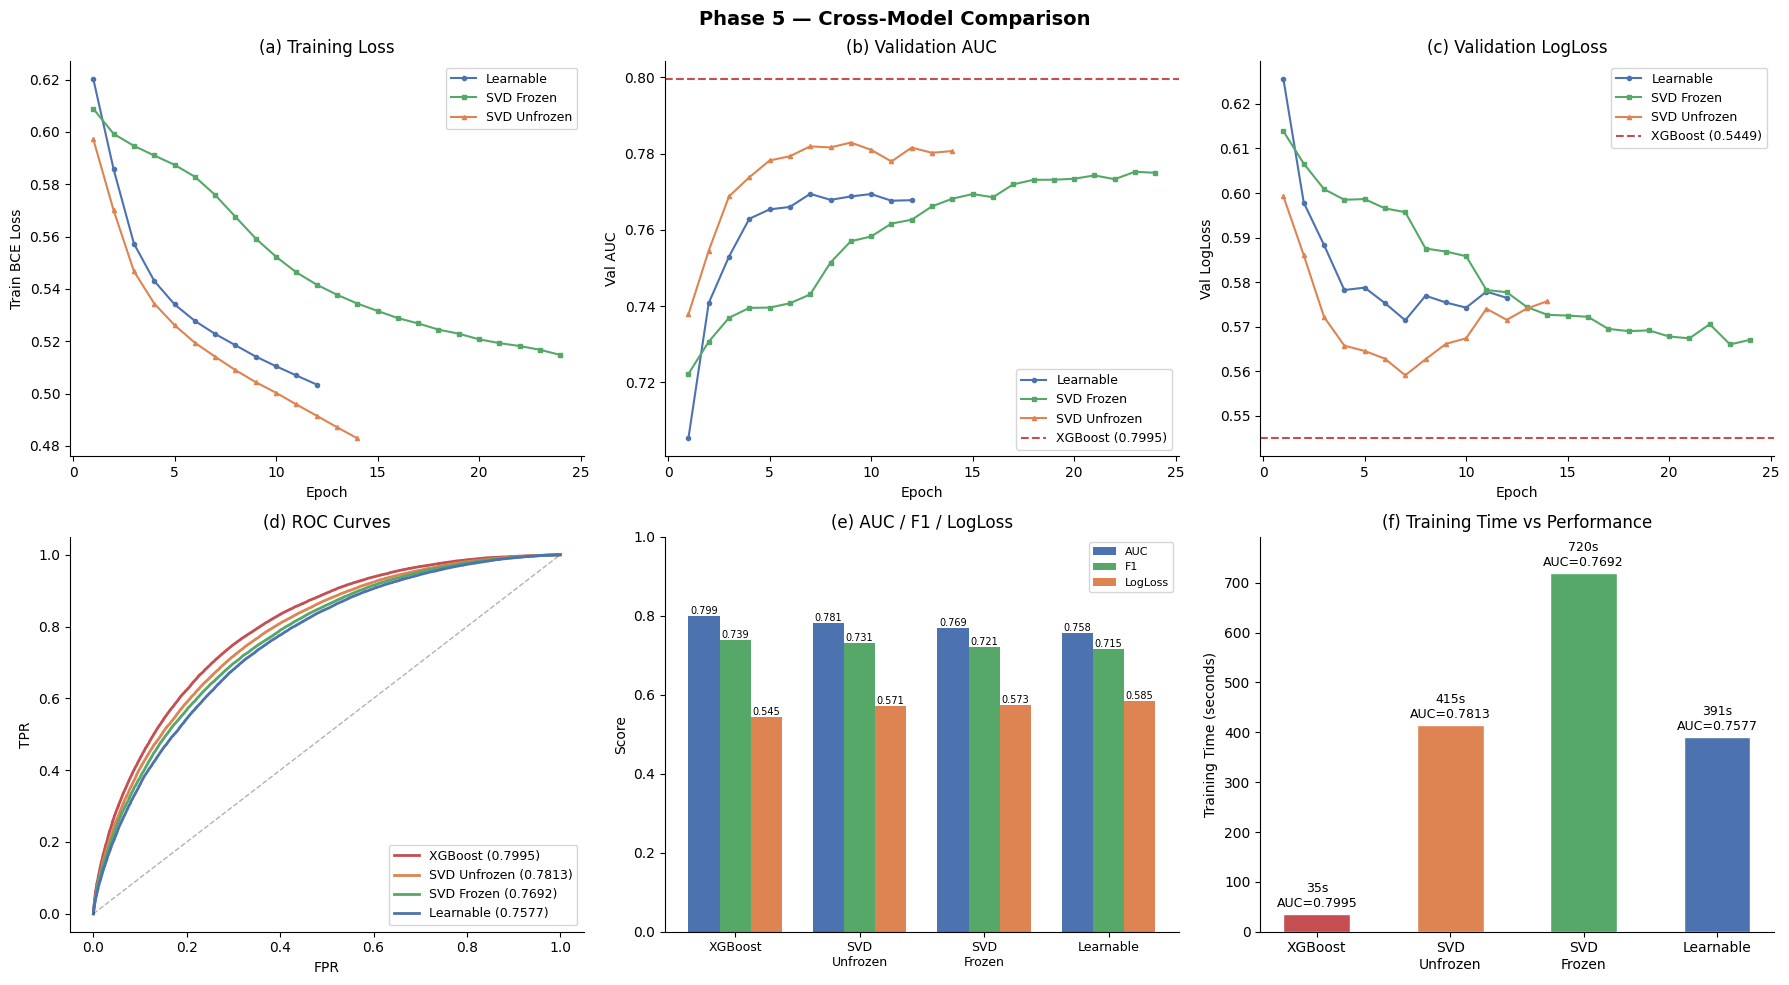

In [ ]:
# ════════════════════════════════════════════════════════════════
# Plots
# ════════════════════════════════════════════════════════════════

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Phase 5 — Cross-Model Comparison',
             fontsize=14, fontweight='bold')

# ── (a) Training Loss Curves ─────────────────────────────────
ax = axes[0, 0]
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.plot(hist_learn['epoch'], hist_learn['train_loss'],
        '-o', color='#4C72B0', markersize=3, lw=1.5,
        label='Learnable')
ax.plot(hist_frozen['epoch'], hist_frozen['train_loss'],
        '-s', color='#55A868', markersize=3, lw=1.5,
        label='SVD Frozen')
ax.plot(hist_unfrozen['epoch'], hist_unfrozen['train_loss'],       # ★ NEW
        '-^', color='#DD8452', markersize=3, lw=1.5,
        label='SVD Unfrozen')
ax.set_xlabel('Epoch'); ax.set_ylabel('Train BCE Loss')
ax.set_title('(a) Training Loss')
ax.legend(fontsize=9)

# ── (b) Val AUC Curves ──────────────────────────────────────
ax = axes[0, 1]
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.plot(hist_learn['epoch'], hist_learn['val_auc'],
        '-o', color='#4C72B0', markersize=3, lw=1.5,
        label='Learnable')
ax.plot(hist_frozen['epoch'], hist_frozen['val_auc'],
        '-s', color='#55A868', markersize=3, lw=1.5,
        label='SVD Frozen')
ax.plot(hist_unfrozen['epoch'], hist_unfrozen['val_auc'],           # ★ NEW
        '-^', color='#DD8452', markersize=3, lw=1.5,
        label='SVD Unfrozen')
ax.axhline(auc_xgb, color='#C44E52', ls='--', lw=1.5,
           label=f'XGBoost ({auc_xgb:.4f})')
ax.set_xlabel('Epoch'); ax.set_ylabel('Val AUC')
ax.set_title('(b) Validation AUC')
ax.legend(fontsize=9)

# ── (c) Val LogLoss Curves ───────────────────────────────────
ax = axes[0, 2]
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.plot(hist_learn['epoch'], hist_learn['val_ll'],
        '-o', color='#4C72B0', markersize=3, lw=1.5,
        label='Learnable')
ax.plot(hist_frozen['epoch'], hist_frozen['val_ll'],
        '-s', color='#55A868', markersize=3, lw=1.5,
        label='SVD Frozen')
ax.plot(hist_unfrozen['epoch'], hist_unfrozen['val_ll'],            # ★ NEW
        '-^', color='#DD8452', markersize=3, lw=1.5,
        label='SVD Unfrozen')
ax.axhline(ll_xgb, color='#C44E52', ls='--', lw=1.5,
           label=f'XGBoost ({ll_xgb:.4f})')
ax.set_xlabel('Epoch'); ax.set_ylabel('Val LogLoss')
ax.set_title('(c) Validation LogLoss')
ax.legend(fontsize=9)

# ── (d) ROC Curves ───────────────────────────────────────────
ax = axes[1, 0]
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
fpr_xgb, tpr_xgb, _ = roc_curve(y_te_xgb, prob_xgb)
fpr_learn, tpr_learn, _ = roc_curve(res_learn['labels'], res_learn['probs'])
fpr_frozen, tpr_frozen, _ = roc_curve(res_frozen['labels'], res_frozen['probs'])
fpr_unfrozen, tpr_unfrozen, _ = roc_curve(res_unfrozen['labels'],  # ★ NEW
                                           res_unfrozen['probs'])

ax.plot(fpr_xgb, tpr_xgb, color='#C44E52', lw=2,
        label=f'XGBoost ({auc_xgb:.4f})')
ax.plot(fpr_unfrozen, tpr_unfrozen, color='#DD8452', lw=2,         # ★ NEW
        label=f'SVD Unfrozen ({res_unfrozen["auc"]:.4f})')
ax.plot(fpr_frozen, tpr_frozen, color='#55A868', lw=2,
        label=f'SVD Frozen ({res_frozen["auc"]:.4f})')
ax.plot(fpr_learn, tpr_learn, color='#4C72B0', lw=2,
        label=f'Learnable ({res_learn["auc"]:.4f})')
ax.plot([0, 1], [0, 1], 'k--', lw=1, alpha=0.3)
ax.set_xlabel('FPR'); ax.set_ylabel('TPR')
ax.set_title('(d) ROC Curves')
ax.legend(fontsize=9, loc='lower right')

# ── (e) Final AUC / LL / F1 Bar Chart ───────────────────────
ax = axes[1, 1]
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
models = ['XGBoost', 'SVD\nUnfrozen', 'SVD\nFrozen', 'Learnable']  # ★ 4 models
x = np.arange(len(models))
w = 0.25

aucs_bar = [auc_xgb, res_unfrozen['auc'], res_frozen['auc'], res_learn['auc']]
lls_bar  = [ll_xgb, res_unfrozen['logloss'], res_frozen['logloss'], res_learn['logloss']]
f1s_bar  = [f1_xgb, f1_unfrozen, f1_frozen, f1_learn]

bars1 = ax.bar(x - w, aucs_bar, w, label='AUC', color='#4C72B0')
bars2 = ax.bar(x,     f1s_bar,  w, label='F1',  color='#55A868')
bars3 = ax.bar(x + w, lls_bar,  w, label='LogLoss', color='#DD8452')

for bars in [bars1, bars2, bars3]:
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                f'{bar.get_height():.3f}', ha='center', fontsize=7)

ax.set_xticks(x)
ax.set_xticklabels(models, fontsize=9)
ax.set_ylabel('Score')
ax.set_title('(e) AUC / F1 / LogLoss')
ax.legend(fontsize=8)
ax.set_ylim(0, 1.0)

# ── (f) Training Time & Efficiency ──────────────────────────
ax = axes[1, 2]
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
models_eff = ['XGBoost', 'SVD\nUnfrozen', 'SVD\nFrozen', 'Learnable']  # ★ 4 models
times  = [xgb_time, unfrozen_time, frozen_time, learn_time]
colors_t = ['#C44E52', '#DD8452', '#55A868', '#4C72B0']
aucs_t = [auc_xgb, res_unfrozen['auc'], res_frozen['auc'], res_learn['auc']]
bars = ax.bar(models_eff, times, color=colors_t, edgecolor='white', width=0.5)
for bar, t, a in zip(bars, times, aucs_t):
    ax.text(bar.get_x() + bar.get_width()/2,
            t + max(times)*0.02,
            f'{t:.0f}s\nAUC={a:.4f}',
            ha='center', fontsize=9)
ax.set_ylabel('Training Time (seconds)')
ax.set_title('(f) Training Time vs Performance')
ax.set_ylim(0, max(times)*1.1)

plt.tight_layout()
plt.show()


════════════════════════════════════════════════════════════
PHASE 5 — EXTENDED DIAGNOSTICS
════════════════════════════════════════════════════════════
  All 3 models aligned with test set (n=102,759)


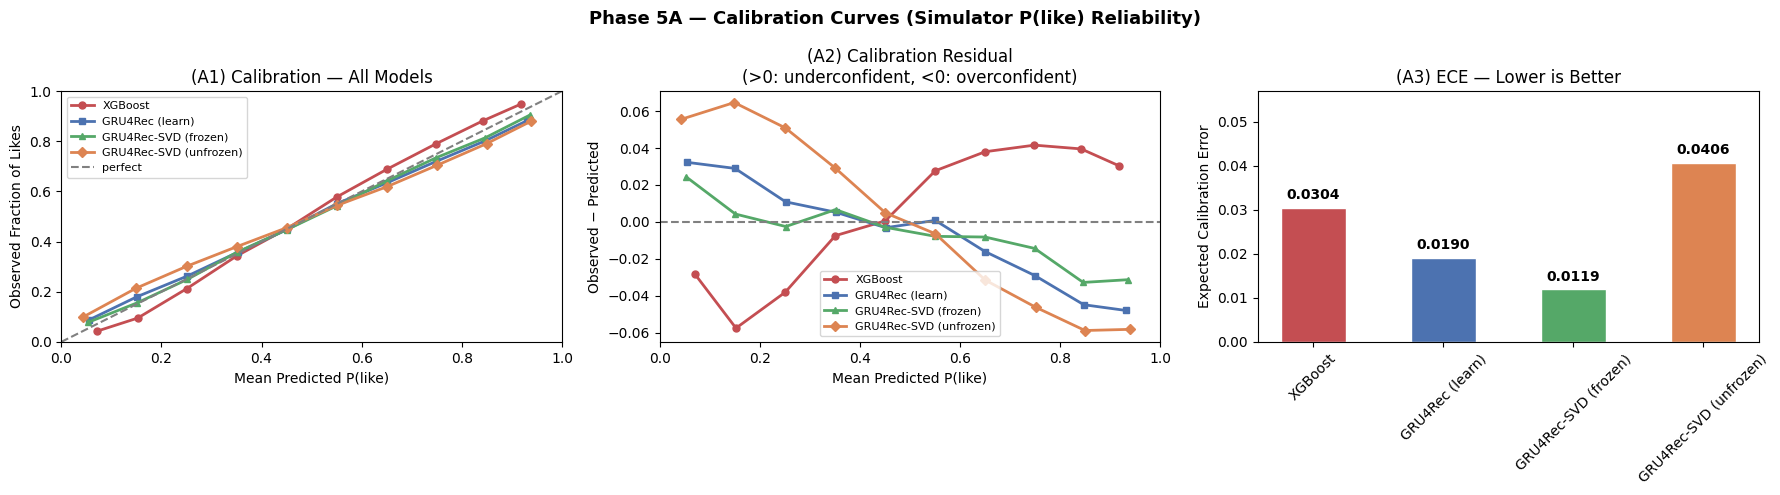


  Calibration Error (ECE):
    XGBoost                   ECE=0.0304
    GRU4Rec (learn)           ECE=0.0190
    GRU4Rec-SVD (frozen)      ECE=0.0119
    GRU4Rec-SVD (unfrozen)    ECE=0.0406


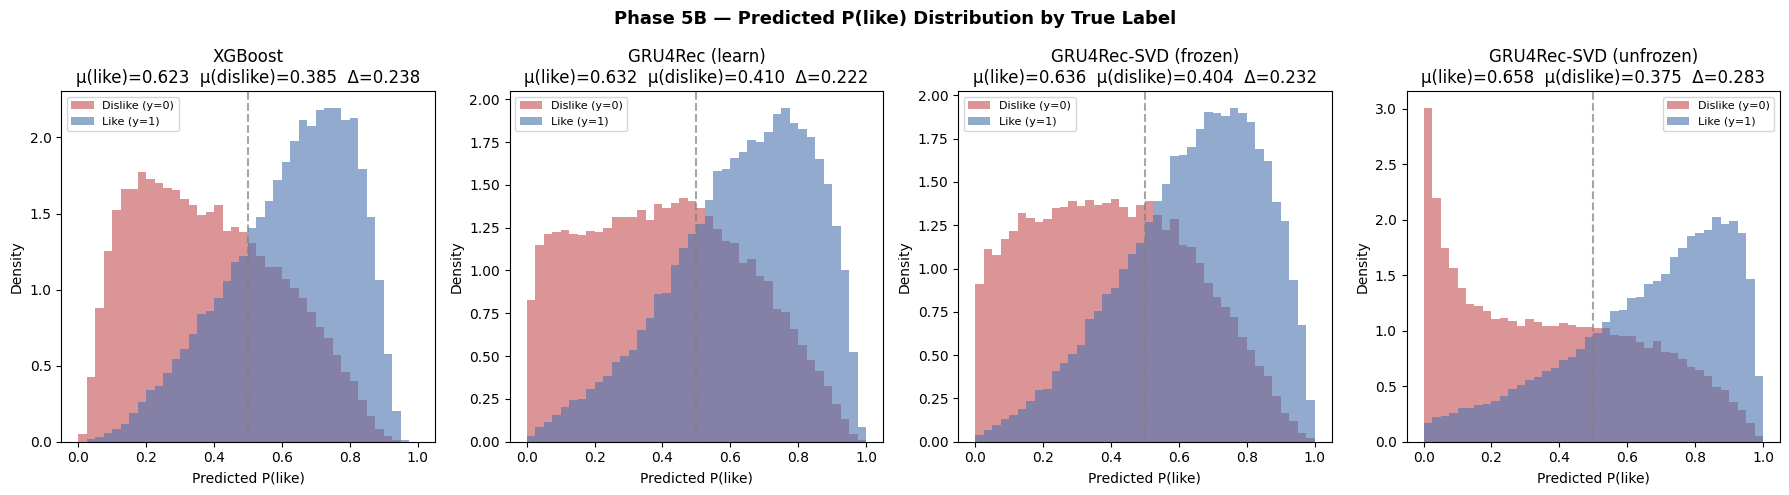


  Score Distribution Summary:
  Model                      μ(like) μ(dislike)   Separation
  ───────────────────────────────────────────────────────
  XGBoost                     0.6230     0.3851       0.2380
  GRU4Rec (learn)             0.6321     0.4100       0.2221
  GRU4Rec-SVD (frozen)        0.6359     0.4044       0.2315
  GRU4Rec-SVD (unfrozen)      0.6579     0.3753       0.2826

════════════════════════════════════════════════════════════
PHASE 5C — PER-USER SEGMENT AUC
════════════════════════════════════════════════════════════

  Segment                  n                 XGBoost         GRU4Rec (learn)    GRU4Rec-SVD (frozen)  GRU4Rec-SVD (unfrozen)
  ───────────────────────────────────────────────────────────────────────────
  Cold (≤20)           1,573                  0.7394                  0.7047                  0.7270                  0.7181
  Regular             20,824                  0.7594                  0.7446                  0.7607                  0.76

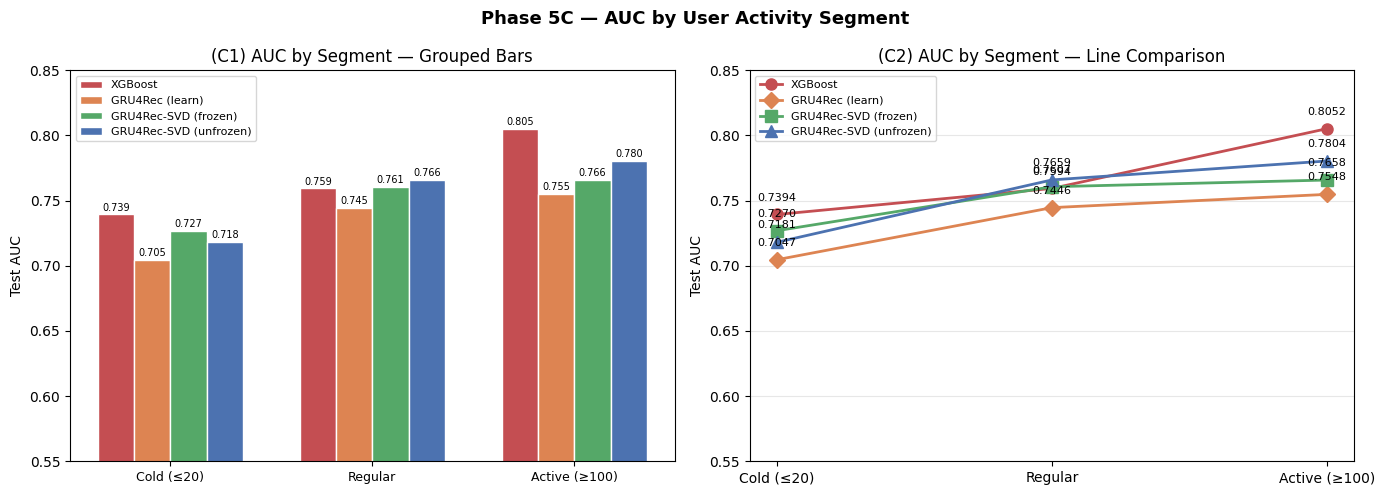


════════════════════════════════════════════════════════════
DIAGNOSTIC CONCLUSIONS
════════════════════════════════════════════════════════════

  (A) Calibration: Lower ECE = more reliable P(like) for RL.
      If GRU4Rec is better calibrated despite lower AUC,
      it may still be a viable simulator for reward signal.

  (B) Score Distribution: Higher separation (Δ) = model is
      more decisive. If GRU4Rec clusters around 0.4-0.6,
      the RL agent receives ambiguous reward signals.

  (C) User Segments: If GRU4Rec closes the AUC gap on Active
      users (rich history), it confirms sequential patterns
      help most when data is abundant.



In [ ]:
# ── Cell: Phase 5 — Extended Diagnostics ─────────────────────
# Three cross-model diagnostics:
#   (A) Calibration Curves
#   (B) Score Distribution (like vs dislike)
#   (C) Per-User Segment AUC

from sklearn.calibration import calibration_curve

print('═' * 60)
print('PHASE 5 — EXTENDED DIAGNOSTICS')
print('═' * 60)

# ── Collect predictions in a unified dict ────────────────────
# XGBoost predictions come from build_svd_X(test), same row order as test
# GRU4Rec predictions come from evaluate() on te_loader_comp (shuffle=False)
# ⇒ All three align with test['user_id'].values

models_diag = {
    'XGBoost': {
        'probs':  prob_xgb,
        'labels': y_te_xgb,
        'color':  '#C44E52',
        'marker': 'o',
    },
    'GRU4Rec (learn)': {
        'probs':  res_learn['probs'],
        'labels': res_learn['labels'],
        'color':  '#4C72B0',
        'marker': 's',
    },
    'GRU4Rec-SVD (frozen)': {
        'probs':  res_frozen['probs'],
        'labels': res_frozen['labels'],
        'color':  '#55A868',
        'marker': '^',
    },
    'GRU4Rec-SVD (unfrozen)': {                                     # ★ NEW
    'probs':  res_unfrozen['probs'],
    'labels': res_unfrozen['labels'],
    'color':  '#DD8452',
    'marker': 'D',
    },
}

# Sanity check: all predictions should have same length as test
for name, d in models_diag.items():
    assert len(d['probs']) == len(test), \
        f"{name}: len(probs)={len(d['probs'])} != len(test)={len(test)}"
print(f'  All 3 models aligned with test set (n={len(test):,})')


# ════════════════════════════════════════════════════════════════
# (A) Calibration Curves
# ════════════════════════════════════════════════════════════════

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Phase 5A — Calibration Curves (Simulator P(like) Reliability)',
             fontsize=13, fontweight='bold')

# (A1) All three on one plot
ax = axes[0]
for name, d in models_diag.items():
    frac_pos, mean_pred = calibration_curve(
        d['labels'], d['probs'], n_bins=10, strategy='uniform')
    ax.plot(mean_pred, frac_pos, f'-{d["marker"]}',
            color=d['color'], lw=2, markersize=5, label=name)
ax.plot([0, 1], [0, 1], '--', color='gray', lw=1.5, label='perfect')
ax.set_xlabel('Mean Predicted P(like)')
ax.set_ylabel('Observed Fraction of Likes')
ax.set_title('(A1) Calibration — All Models')
ax.legend(fontsize=8)
ax.set_xlim(0, 1); ax.set_ylim(0, 1)

# ── (A2) Calibration Residual — deviation from perfect ───────
ax = axes[1]
for name, d in models_diag.items():
    frac_pos, mean_pred = calibration_curve(
        d['labels'], d['probs'], n_bins=10, strategy='uniform')
    residual = frac_pos - mean_pred  # >0 = 低估, <0 = 高估
    ax.plot(mean_pred, residual, f'-{d["marker"]}',
            color=d['color'], lw=2, markersize=5, label=name)
ax.axhline(0, color='gray', ls='--', lw=1.5)
ax.set_xlabel('Mean Predicted P(like)')
ax.set_ylabel('Observed − Predicted')
ax.set_title('(A2) Calibration Residual\n(>0: underconfident, <0: overconfident)')
ax.legend(fontsize=8)
ax.set_xlim(0, 1)

# (A3) Calibration Error (ECE) bar chart
ax = axes[2]
ece_vals = {}
for name, d in models_diag.items():
    frac_pos_i, mean_pred_i = calibration_curve(
        d['labels'], d['probs'], n_bins=10, strategy='uniform')
    # ECE = weighted average of |frac_pos - mean_pred| per bin
    bins_edges_i = np.linspace(0, 1, 11)
    bin_counts = []
    for b in range(10):
        mask_b = (d['probs'] >= bins_edges_i[b]) & \
                 (d['probs'] < bins_edges_i[b+1])
        bin_counts.append(mask_b.sum())
    # match lengths (calibration_curve may skip empty bins)
    n_bins_actual = len(frac_pos_i)
    bin_counts_matched = np.array(bin_counts[:n_bins_actual])
    total = bin_counts_matched.sum()
    if total > 0:
        ece = np.sum(bin_counts_matched / total *
                     np.abs(frac_pos_i - mean_pred_i))
    else:
        ece = 0.0
    ece_vals[name] = ece

bars = ax.bar(ece_vals.keys(), ece_vals.values(),
              color=[d['color'] for d in models_diag.values()],
              edgecolor='white', width=0.5)
for bar, v in zip(bars, ece_vals.values()):
    ax.text(bar.get_x() + bar.get_width()/2, v + 0.002,
            f'{v:.4f}', ha='center', fontsize=10, fontweight='bold')
ax.set_ylabel('Expected Calibration Error')
ax.set_title('(A3) ECE — Lower is Better')
ax.tick_params(axis='x', labelrotation=45)
ax.set_ylim(0, max(ece_vals.values()) * 1.4)

plt.tight_layout()
plt.show()

print('\n  Calibration Error (ECE):')
for name, ece in ece_vals.items():
    print(f'    {name:<25} ECE={ece:.4f}')


# ════════════════════════════════════════════════════════════════
# (B) Score Distribution — P(like) by true label
# ════════════════════════════════════════════════════════════════

fig, axes = plt.subplots(1, 4, figsize=(18, 5))
fig.suptitle('Phase 5B — Predicted P(like) Distribution by True Label',
             fontsize=13, fontweight='bold')

for ax, (name, d) in zip(axes, models_diag.items()):
    probs  = d['probs']
    labels = d['labels'].astype(int)
    bins_h = np.linspace(0, 1, 41)  # 40 bins

    ax.hist(probs[labels == 0], bins=bins_h, alpha=0.6,
            color='#C44E52', label='Dislike (y=0)', density=True)
    ax.hist(probs[labels == 1], bins=bins_h, alpha=0.6,
            color='#4C72B0', label='Like (y=1)', density=True)
    ax.axvline(0.5, color='gray', ls='--', lw=1.5, alpha=0.7)

    # stats
    mean_pos = probs[labels == 1].mean()
    mean_neg = probs[labels == 0].mean()
    separation = mean_pos - mean_neg
    ax.set_title(f'{name}\n'
                 f'μ(like)={mean_pos:.3f}  μ(dislike)={mean_neg:.3f}  '
                 f'Δ={separation:.3f}')
    ax.set_xlabel('Predicted P(like)')
    ax.set_ylabel('Density')

    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

print('\n  Score Distribution Summary:')
print(f'  {"Model":<25} {"μ(like)":>8} {"μ(dislike)":>10} '
      f'{"Separation":>12}')
print(f'  {"─" * 55}')
for name, d in models_diag.items():
    probs  = d['probs']
    labels = d['labels'].astype(int)
    ml = probs[labels == 1].mean()
    md = probs[labels == 0].mean()
    print(f'  {name:<25} {ml:>8.4f} {md:>10.4f} {ml-md:>12.4f}')


# ════════════════════════════════════════════════════════════════
# (C) Per-User Segment AUC
# ════════════════════════════════════════════════════════════════

print(f'\n{"═" * 60}')
print('PHASE 5C — PER-USER SEGMENT AUC')
print(f'{"═" * 60}')

# Define segments from training set
user_n       = train.groupby('user_id').size()
cold_users   = set(user_n[user_n <= 20].index)
active_users = set(user_n[user_n >= 100].index)

test_uids = test['user_id'].values
mask_cold    = np.array([u in cold_users   for u in test_uids])
mask_active  = np.array([u in active_users for u in test_uids])
mask_regular = ~mask_cold & ~mask_active

segments = [
    ('Cold (≤20)',    mask_cold),
    ('Regular',       mask_regular),
    ('Active (≥100)', mask_active),
]

# Compute AUC per segment per model
seg_auc = {}  # {model_name: {segment: auc}}
for name, d in models_diag.items():
    seg_auc[name] = {}
    for seg_label, mask in segments:
        if mask.sum() > 50:  # need enough samples
            try:
                auc_seg = roc_auc_score(d['labels'][mask], d['probs'][mask])
            except ValueError:
                auc_seg = float('nan')
        else:
            auc_seg = float('nan')
        seg_auc[name][seg_label] = auc_seg

# Print table
print(f'\n  {"Segment":<18} {"n":>7}', end='')
for name in models_diag:
    print(f'  {name:>22}', end='')
print()
print(f'  {"─" * 75}')
for seg_label, mask in segments:
    n = mask.sum()
    print(f'  {seg_label:<18} {n:>7,}', end='')
    for name in models_diag:
        v = seg_auc[name][seg_label]
        print(f'  {v:>22.4f}', end='')
    print()

# (C) Plot: grouped bar chart + line overlay
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Phase 5C — AUC by User Activity Segment',
             fontsize=13, fontweight='bold')

# (C1) Grouped bar chart
ax = axes[0]
seg_labels = [s[0] for s in segments]
x = np.arange(len(seg_labels))
w = 0.18
colors_m = ['#C44E52', '#DD8452', '#55A868', '#4C72B0']

for i, (name, d_color) in enumerate(zip(models_diag.keys(),
                                         colors_m)):
    vals = [seg_auc[name][s] for s in seg_labels]
    bars = ax.bar(x + i*w - 1.5*w, vals, w, label=name,
                  color=d_color, edgecolor='white')
    for bar, v in zip(bars, vals):
        if not np.isnan(v):
            ax.text(bar.get_x() + bar.get_width()/2, v + 0.003,
                    f'{v:.3f}', ha='center', fontsize=7)

ax.set_xticks(x)
ax.set_xticklabels(seg_labels, fontsize=9)
ax.set_ylabel('Test AUC')
ax.set_title('(C1) AUC by Segment — Grouped Bars')
ax.legend(fontsize=8)
ax.set_ylim(0.55, 0.85)

# (C2) Line chart (Phase 5 standard style)
ax = axes[1]
for name, d_color, marker in zip(models_diag.keys(), colors_m,
                                  ['o','D', 's', '^']):
    vals = [seg_auc[name][s] for s in seg_labels]
    ax.plot(seg_labels, vals, f'-{marker}', color=d_color,
            lw=2, markersize=8, label=name)
    for j, v in enumerate(vals):
        if not np.isnan(v):
            ax.annotate(f'{v:.4f}', (j, v),
                        textcoords='offset points',
                        xytext=(0, 10), ha='center', fontsize=8)

ax.set_ylabel('Test AUC')
ax.set_title('(C2) AUC by Segment — Line Comparison')
ax.legend(fontsize=8)
ax.set_ylim(0.55, 0.85)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

print(f'\n{"═" * 60}')
print('DIAGNOSTIC CONCLUSIONS')
print(f'{"═" * 60}')
print('''
  (A) Calibration: Lower ECE = more reliable P(like) for RL.
      If GRU4Rec is better calibrated despite lower AUC,
      it may still be a viable simulator for reward signal.

  (B) Score Distribution: Higher separation (Δ) = model is
      more decisive. If GRU4Rec clusters around 0.4-0.6,
      the RL agent receives ambiguous reward signals.

  (C) User Segments: If GRU4Rec closes the AUC gap on Active
      users (rich history), it confirms sequential patterns
      help most when data is abundant.
''')

In [16]:
print('\n── 4. GRU4Rec-SVD Unfrozen (T=100, SVD=64d, hidden=128)')
import time
from sklearn.metrics import roc_curve, roc_auc_score, log_loss, f1_score

T_COMP = 100
tr_ds_comp = TrainSeqDataset(user_sequences, max_len=T_COMP)
va_ds_comp = SeqDataset(val,  user_sequences, max_len=T_COMP)
te_ds_comp = SeqDataset(test, user_sequences, max_len=T_COMP)

tr_loader_comp = DataLoader(tr_ds_comp, batch_size=512, shuffle=True,
                             num_workers=2, pin_memory=True)
va_loader_comp = DataLoader(va_ds_comp, batch_size=1024, shuffle=False,
                             num_workers=2, pin_memory=True)
te_loader_comp = DataLoader(te_ds_comp, batch_size=1024, shuffle=False,
                             num_workers=2, pin_memory=True)

svd64 = TruncatedSVD(n_components=64, random_state=RANDOM_SEED)
U_svd64 = svd64.fit_transform(mat)
V_svd64 = normalize(svd64.components_.T)

svd_weight64 = np.zeros((n_items, 64), dtype=np.float32)


model_unfrozen = GRU4RecSVD(svd_weight64, hidden_dim=128,
                              n_layers=1, dropout=0.2,
                              freeze_embed=False).to(device)
opt_unfrozen = torch.optim.Adam(model_unfrozen.parameters(), lr=1e-3)
crit_unfrozen = nn.BCEWithLogitsLoss()
n_params_unfrozen = sum(p.numel() for p in model_unfrozen.parameters())

hist_unfrozen = {'epoch': [], 'train_loss': [], 'val_auc': [],
                 'val_ll': [], 'time': []}
best_auc_unfrozen = 0
best_ep_unfrozen  = 0
no_imp = 0

t0 = time.time()
for epoch in range(1, 25):
    ep_t0 = time.time()
    tl = train_one_epoch(model_unfrozen, tr_loader_comp, opt_unfrozen,
                          crit_unfrozen, device)
    vr = evaluate(model_unfrozen, va_loader_comp, crit_unfrozen, device)
    ep_time = time.time() - ep_t0

    hist_unfrozen['epoch'].append(epoch)
    hist_unfrozen['train_loss'].append(tl)
    hist_unfrozen['val_auc'].append(vr['auc'])
    hist_unfrozen['val_ll'].append(vr['logloss'])
    hist_unfrozen['time'].append(ep_time)

    imp = '★' if vr['auc'] > best_auc_unfrozen else ''
    if epoch <= 3 or imp or epoch % 5 == 0:
        print(f'  Epoch {epoch:2d}  train_loss={tl:.4f}  '
              f'val_AUC={vr["auc"]:.4f}  val_LL={vr["logloss"]:.4f}  '
              f'({ep_time:.1f}s)  {imp}')

    if vr['auc'] > best_auc_unfrozen:
        best_auc_unfrozen = vr['auc']
        best_ep_unfrozen  = epoch
        no_imp = 0
        torch.save(model_unfrozen.state_dict(), 'phase5_unfrozen_best.pt')
    else:
        no_imp += 1
        if no_imp >= 5:
            print(f'  Early stop at epoch {epoch} (best={best_ep_unfrozen})')
            break

unfrozen_time = time.time() - t0
model_unfrozen.load_state_dict(torch.load('phase5_unfrozen_best.pt'))
res_unfrozen = evaluate(model_unfrozen, te_loader_comp, crit_unfrozen, device)
pred_unfrozen = (res_unfrozen['probs'] >= 0.5).astype(int)
f1_unfrozen = f1_score(res_unfrozen['labels'], pred_unfrozen)

print(f'\n  AUC={res_unfrozen["auc"]:.4f}  LL={res_unfrozen["logloss"]:.4f}  '
      f'F1={f1_unfrozen:.4f}')
print(f'  Params: {n_params_unfrozen:,}  Time: {unfrozen_time:.1f}s  '
      f'Best epoch: {best_ep_unfrozen}')


── 4. GRU4Rec-SVD Unfrozen (T=100, SVD=64d, hidden=128)
  Epoch  1  train_loss=0.5976  val_AUC=0.7330  val_LL=0.6038  (28.5s)  ★
  Epoch  2  train_loss=0.5735  val_AUC=0.7503  val_LL=0.5878  (27.9s)  ★
  Epoch  3  train_loss=0.5549  val_AUC=0.7591  val_LL=0.5809  (26.5s)  ★
  Epoch  4  train_loss=0.5440  val_AUC=0.7670  val_LL=0.5728  (27.5s)  ★
  Epoch  5  train_loss=0.5367  val_AUC=0.7703  val_LL=0.5710  (26.2s)  ★
  Epoch  6  train_loss=0.5306  val_AUC=0.7730  val_LL=0.5732  (28.3s)  ★
  Epoch  7  train_loss=0.5259  val_AUC=0.7752  val_LL=0.5664  (25.7s)  ★
  Epoch  9  train_loss=0.5169  val_AUC=0.7756  val_LL=0.5686  (27.7s)  ★
  Epoch 10  train_loss=0.5126  val_AUC=0.7780  val_LL=0.5679  (26.9s)  ★
  Epoch 11  train_loss=0.5083  val_AUC=0.7799  val_LL=0.5655  (27.5s)  ★
  Epoch 15  train_loss=0.4907  val_AUC=0.7764  val_LL=0.5733  (26.1s)  
  Early stop at epoch 16 (best=11)

  AUC=0.7788  LL=0.5706  F1=0.7327
  Params: 336,577  Time: 432.9s  Best epoch: 11


In [16]:
# ============================================================
# Phase 6(a): Balanced cold-movie holdout split
# ============================================================

def split_with_cold_movies_balanced(
    ratings_df,
    cold_movie_frac=0.10,
    min_movie_interactions=20,
    max_movie_interactions=200,
    random_state=42
):
    rng = np.random.RandomState(random_state)

    movie_counts = ratings_df.groupby('movie_id').size()
    eligible_movies = movie_counts[
        (movie_counts >= min_movie_interactions) &
        (movie_counts <= max_movie_interactions)
    ].index.values

    n_cold = max(1, int(len(eligible_movies) * cold_movie_frac))
    cold_movies = set(rng.choice(eligible_movies, size=n_cold, replace=False))

    cold_mask = ratings_df['movie_id'].isin(cold_movies)
    cold_df = ratings_df[cold_mask].copy()
    seen_df = ratings_df[~cold_mask].copy()

    train_seen, val_seen, test_seen = temporal_split_per_user(seen_df)

    test_all = pd.concat([test_seen, cold_df], axis=0)
    test_all = test_all.sort_values(['user_id', 'timestamp']).reset_index(drop=True)

    return (
        train_seen.reset_index(drop=True),
        val_seen.reset_index(drop=True),
        test_all.reset_index(drop=True),
        cold_movies
    )

In [14]:
# ============================================================
# Phase 6(b) : Build GRU data under balanced cold-movie split
# ============================================================

train_gcm, val_gcm, test_gcm, cold_movies_bal = split_with_cold_movies_balanced(
    ratings,
    cold_movie_frac=0.10,
    min_movie_interactions=20,
    max_movie_interactions=200,
    random_state=RANDOM_SEED
)

print("Train size:", len(train_gcm))
print("Val size  :", len(val_gcm))
print("Test size :", len(test_gcm))
print("Balanced cold movies held out from train:", len(cold_movies_bal))

print("Any cold movies in train?", train_gcm['movie_id'].isin(cold_movies_bal).any())
print("Any cold movies in val?  ", val_gcm['movie_id'].isin(cold_movies_bal).any())
print("Cold-movie rows in test  :", test_gcm['movie_id'].isin(cold_movies_bal).sum())

# --- movie_id -> movie_idx mapping ---
all_movie_ids_gcm = sorted(ratings['movie_id'].unique())
mid2idx_gcm = {mid: i + 1 for i, mid in enumerate(all_movie_ids_gcm)}
n_items_gcm = len(all_movie_ids_gcm) + 1   # 0 reserved for padding

train_gcm = train_gcm.copy()
val_gcm   = val_gcm.copy()
test_gcm  = test_gcm.copy()

train_gcm['movie_idx'] = train_gcm['movie_id'].map(mid2idx_gcm)
val_gcm['movie_idx']   = val_gcm['movie_id'].map(mid2idx_gcm)
test_gcm['movie_idx']  = test_gcm['movie_id'].map(mid2idx_gcm)

# --- build user sequences from TRAIN only ---
user_sequences_gcm = {}
for uid, grp in train_gcm.sort_values(['user_id', 'timestamp']).groupby('user_id'):
    user_sequences_gcm[uid] = list(zip(grp['movie_idx'].values, grp['like'].values))

seq_lens = [len(v) for v in user_sequences_gcm.values()]
print(f'Users with sequences: {len(user_sequences_gcm):,}')
print(f'Sequence length: min={min(seq_lens)}, median={int(np.median(seq_lens))}, max={max(seq_lens)}')

[per-user split] train 786,992 | val 98,311 | test 101,419
Train size: 786992
Val size  : 98311
Test size : 114906
Balanced cold movies held out from train: 162
Any cold movies in train? False
Any cold movies in val?   False
Cold-movie rows in test  : 13487
Users with sequences: 6,040
Sequence length: min=14, median=76, max=1781


In [15]:
# ============================================================
# Phase 6(c): Build GRU datasets/loaders (best config uses T=100)
# ============================================================

MAX_LEN_GCM = 100

tr_ds_gcm = TrainSeqDataset(user_sequences_gcm, max_len=MAX_LEN_GCM)
va_ds_gcm = SeqDataset(val_gcm,  user_sequences_gcm, max_len=MAX_LEN_GCM)
te_ds_gcm = SeqDataset(test_gcm, user_sequences_gcm, max_len=MAX_LEN_GCM)

tr_loader_gcm = DataLoader(tr_ds_gcm, batch_size=512, shuffle=True,
                           num_workers=2, pin_memory=True)
va_loader_gcm = DataLoader(va_ds_gcm, batch_size=1024, shuffle=False,
                           num_workers=2, pin_memory=True)
te_loader_gcm = DataLoader(te_ds_gcm, batch_size=1024, shuffle=False,
                           num_workers=2, pin_memory=True)

print("Train samples:", len(tr_ds_gcm))
print("Val samples  :", len(va_ds_gcm))
print("Test samples :", len(te_ds_gcm))

Train samples: 780952
Val samples  : 98311
Test samples : 114906


In [17]:
# ============================================================
# Phase 6(d): Train GRU4Rec on balanced cold-movie split
# Best config from v2: embed=64, hidden=128, T=100
# ============================================================

model_gcm = GRU4Rec(
    n_items_gcm,
    embed_dim=64,
    hidden_dim=128,
    n_layers=1,
    dropout=0.2
).to(device)

optimizer_gcm = torch.optim.Adam(model_gcm.parameters(), lr=1e-3)
criterion_gcm = nn.BCEWithLogitsLoss()

best_val_auc_gcm = 0
best_epoch_gcm   = 0
no_improve_gcm   = 0

history_gcm = {'train_loss': [], 'val_loss': [], 'val_auc': [], 'val_ll': []}

print('Training GRU4Rec on balanced cold-movie split (embed=64, hidden=128, T=100)')
for epoch in range(1, 21):
    train_loss = train_one_epoch(model_gcm, tr_loader_gcm, optimizer_gcm, criterion_gcm, device)
    val_res    = evaluate(model_gcm, va_loader_gcm, criterion_gcm, device)

    history_gcm['train_loss'].append(train_loss)
    history_gcm['val_loss'].append(val_res['loss'])
    history_gcm['val_auc'].append(val_res['auc'])
    history_gcm['val_ll'].append(val_res['logloss'])

    improved = '★' if val_res['auc'] > best_val_auc_gcm else ''
    if epoch <= 3 or improved or epoch % 5 == 0:
        print(f'Epoch {epoch:2d} | train_loss={train_loss:.4f} | '
              f'val_AUC={val_res["auc"]:.4f} | val_LL={val_res["logloss"]:.4f} {improved}')

    if val_res['auc'] > best_val_auc_gcm:
        best_val_auc_gcm = val_res['auc']
        best_epoch_gcm   = epoch
        no_improve_gcm   = 0
        torch.save(model_gcm.state_dict(), 'gru4rec_balanced_cold_movie_best.pt')
    else:
        no_improve_gcm += 1
        if no_improve_gcm >= 5:
            print(f'\nEarly stopping at epoch {epoch} (best={best_epoch_gcm}, AUC={best_val_auc_gcm:.4f})')
            break

model_gcm.load_state_dict(torch.load('gru4rec_balanced_cold_movie_best.pt'))
test_res_gcm = evaluate(model_gcm, te_loader_gcm, criterion_gcm, device)

print(f'\n── GRU4Rec on balanced cold-movie split ──')
print(f'Best epoch: {best_epoch_gcm}')
print(f'[val ] AUC={best_val_auc_gcm:.4f}')
print(f'[test] AUC={test_res_gcm["auc"]:.4f}  LogLoss={test_res_gcm["logloss"]:.4f}')

Training GRU4Rec on balanced cold-movie split (embed=64, hidden=128, T=100)
Epoch  1 | train_loss=0.6212 | val_AUC=0.6997 | val_LL=0.6298 ★
Epoch  2 | train_loss=0.5910 | val_AUC=0.7381 | val_LL=0.6073 ★
Epoch  3 | train_loss=0.5598 | val_AUC=0.7570 | val_LL=0.5847 ★
Epoch  4 | train_loss=0.5432 | val_AUC=0.7617 | val_LL=0.5787 ★
Epoch  5 | train_loss=0.5345 | val_AUC=0.7654 | val_LL=0.5807 ★
Epoch  6 | train_loss=0.5279 | val_AUC=0.7693 | val_LL=0.5716 ★
Epoch 10 | train_loss=0.5105 | val_AUC=0.7687 | val_LL=0.5755 

Early stopping at epoch 11 (best=6, AUC=0.7693)

── GRU4Rec on balanced cold-movie split ──
Best epoch: 6
[val ] AUC=0.7693
[test] AUC=0.7467  LogLoss=0.5975


In [18]:
print(test_res_gcm.keys())

dict_keys(['loss', 'auc', 'logloss', 'probs', 'labels'])


In [20]:
# ============================================================
# Split GRU test results into seen-movie vs cold-movie
# ============================================================
from sklearn.metrics import roc_auc_score, log_loss, f1_score
import numpy as np
import pandas as pd

def eval_subset_from_probs(df, label):
    if len(df) == 0:
        return {
            'subset': label,
            'n_rows': 0,
            'n_users': 0,
            'n_movies': 0,
            'pos_rate': np.nan,
            'auc': np.nan,
            'logloss': np.nan,
            'f1': np.nan
        }

    y = df['like'].astype(int).values
    p = np.clip(df['pred_prob'].values, 1e-7, 1 - 1e-7)
    pred = (p >= 0.5).astype(int)

    return {
        'subset': label,
        'n_rows': len(df),
        'n_users': df['user_id'].nunique(),
        'n_movies': df['movie_id'].nunique(),
        'pos_rate': df['like'].mean(),
        'auc': roc_auc_score(y, p) if len(np.unique(y)) >= 2 else np.nan,
        'logloss': log_loss(y, p),
        'f1': f1_score(y, pred)
    }

# SeqDataset preserves row order over kept samples, so align using only rows with seen-user histories
test_eval_gcm = test_gcm[test_gcm['user_id'].isin(user_sequences_gcm.keys())].copy().reset_index(drop=True)
test_eval_gcm['pred_prob'] = test_res_gcm['probs']
test_eval_gcm['is_cold_movie'] = test_eval_gcm['movie_id'].isin(cold_movies_bal).astype(int)

results_gru_gcm = pd.DataFrame([
    eval_subset_from_probs(test_eval_gcm, 'all_test'),
    eval_subset_from_probs(test_eval_gcm[test_eval_gcm['is_cold_movie'] == 0], 'seen_movies'),
    eval_subset_from_probs(test_eval_gcm[test_eval_gcm['is_cold_movie'] == 1], 'cold_movies_balanced'),
])

display(results_gru_gcm)

,subset,n_rows,n_users,n_movies,pos_rate,auc,logloss,f1
0,all_test,114906,6040,3443,0.505552,0.746718,0.597475,0.702197
1,seen_movies,101419,6040,3281,0.518463,0.760267,0.582963,0.719001
2,cold_movies_balanced,13487,3359,162,0.408467,0.622490,0.706602,0.553103


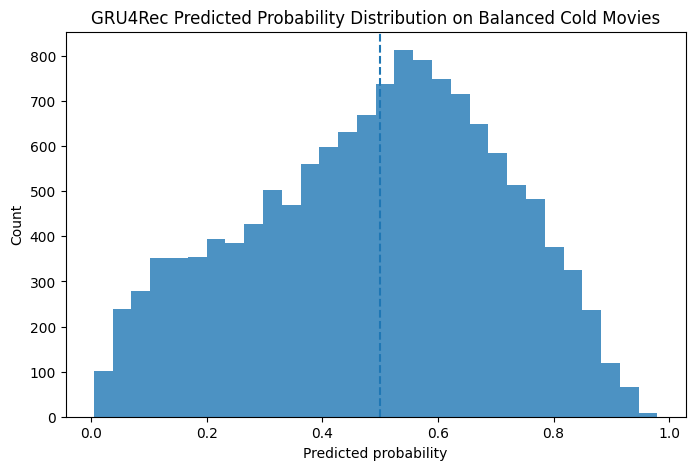

In [22]:
import matplotlib.pyplot as plt

gru_cold_probs = test_eval_gcm.loc[
    test_eval_gcm['is_cold_movie'] == 1, 'pred_prob'
].values

plt.figure(figsize=(8,5))
plt.hist(gru_cold_probs, bins=30, alpha=0.8)
plt.axvline(0.5, linestyle='--')
plt.xlabel('Predicted probability')
plt.ylabel('Count')
plt.title('GRU4Rec Predicted Probability Distribution on Balanced Cold Movies')
plt.show()

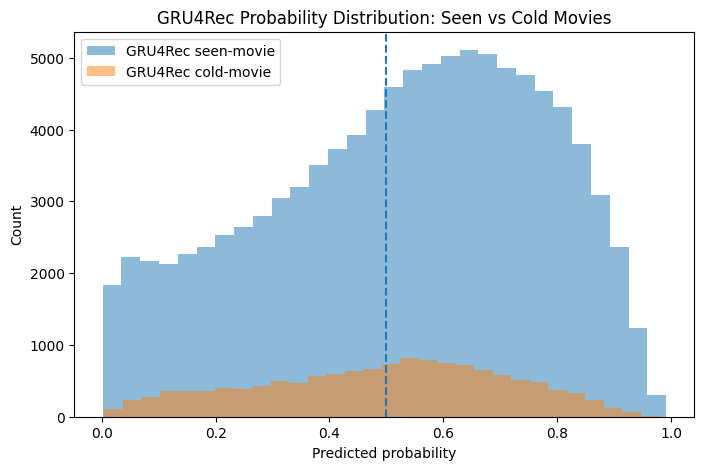

In [23]:
import matplotlib.pyplot as plt

gru_seen_probs = test_eval_gcm.loc[
    test_eval_gcm['is_cold_movie'] == 0, 'pred_prob'
].values

gru_cold_probs = test_eval_gcm.loc[
    test_eval_gcm['is_cold_movie'] == 1, 'pred_prob'
].values

plt.figure(figsize=(8,5))
plt.hist(gru_seen_probs, bins=30, alpha=0.5, label='GRU4Rec seen-movie')
plt.hist(gru_cold_probs, bins=30, alpha=0.5, label='GRU4Rec cold-movie')
plt.axvline(0.5, linestyle='--')
plt.xlabel('Predicted probability')
plt.ylabel('Count')
plt.title('GRU4Rec Probability Distribution: Seen vs Cold Movies')
plt.legend()
plt.show()

In [24]:
from sklearn.metrics import precision_score, recall_score, f1_score
import pandas as pd

def threshold_stats(df, label):
    y = df['like'].astype(int).values
    p = df['pred_prob'].values
    pred = (p >= 0.5).astype(int)
    return {
        'subset': label,
        'pred_pos_rate': pred.mean(),
        'precision@0.5': precision_score(y, pred, zero_division=0),
        'recall@0.5': recall_score(y, pred, zero_division=0),
        'f1@0.5': f1_score(y, pred, zero_division=0),
    }

gru_thresh = pd.DataFrame([
    threshold_stats(test_eval_gcm[test_eval_gcm['is_cold_movie'] == 0], 'seen_movies'),
    threshold_stats(test_eval_gcm[test_eval_gcm['is_cold_movie'] == 1], 'cold_movies_balanced'),
])

display(gru_thresh)

,subset,pred_pos_rate,precision@0.5,recall@0.5,f1@0.5
0,seen_movies,0.575415,0.683420,0.758491,0.719001
1,cold_movies_balanced,0.518648,0.494353,0.627700,0.553103


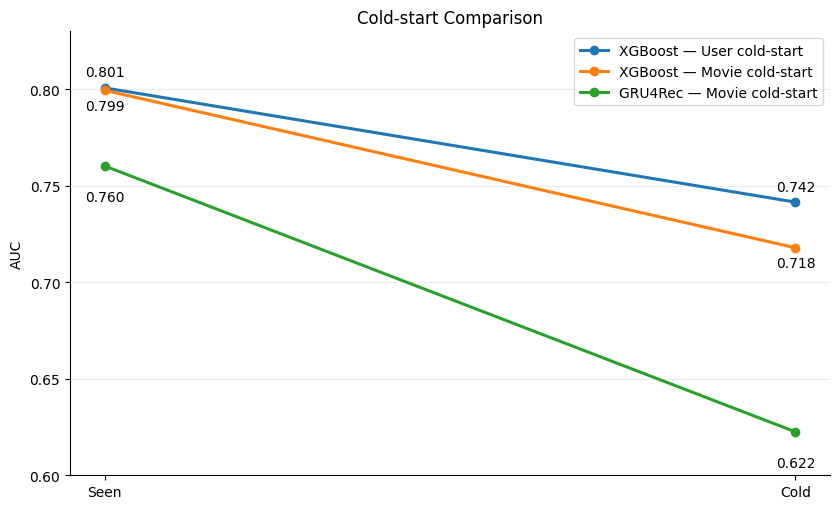

In [6]:
import matplotlib.pyplot as plt

# XGBoost
xgb_seen_user = 0.800712
xgb_cold_user = 0.741509

xgb_seen_movie = 0.799448
xgb_cold_movie = 0.717848

# GRU4Rec
gru_seen_movie = 0.760267
gru_cold_movie = 0.622490

x = [0, 1]
x_labels = ['Seen', 'Cold']

plt.figure(figsize=(8.5, 5.2))

# XGB user cold-start
plt.plot(
    x, [xgb_seen_user, xgb_cold_user],
    marker='o', linewidth=2.2, label='XGBoost — User cold-start'
)

# XGB movie cold-start
plt.plot(
    x, [xgb_seen_movie, xgb_cold_movie],
    marker='o', linewidth=2.2, label='XGBoost — Movie cold-start'
)

# GRU movie cold-start
plt.plot(
    x, [gru_seen_movie, gru_cold_movie],
    marker='o', linewidth=2.2, label='GRU4Rec — Movie cold-start'
)

# annotate values
vals = [
    (xgb_seen_user, xgb_cold_user),
    (xgb_seen_movie, xgb_cold_movie),
    (gru_seen_movie, gru_cold_movie),
]
offsets = [0.006, -0.010, -0.018]

for (y0, y1), off in zip(vals, offsets):
    plt.text(0, y0 + off, f"{y0:.3f}", ha='center')
    plt.text(1, y1 + off, f"{y1:.3f}", ha='center')

plt.xticks(x, x_labels)
plt.ylabel('AUC')
plt.title('Cold-start Comparison')
plt.ylim(0.60, 0.83)
plt.grid(axis='y', alpha=0.25)
ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.legend()
plt.tight_layout()
plt.show()

In [11]:
# ============================================================
# GRU4Rec ablation: n_layers = 2
# Keep all other settings the same as the best baseline
# ============================================================

import random
import numpy as np
import torch
import torch.nn as nn

# ---- reproducibility ----
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)
torch.cuda.manual_seed_all(RANDOM_SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

# ---- keep your best settings unchanged ----
EMBED_DIM  = 64
HIDDEN_DIM = 128
N_LAYERS   = 2
DROPOUT    = 0.2
LR         = 1e-3
EPOCHS     = 20
PATIENCE   = 5

model_l2 = GRU4Rec(
    n_items,
    embed_dim=EMBED_DIM,
    hidden_dim=HIDDEN_DIM,
    n_layers=N_LAYERS,
    dropout=DROPOUT
).to(device)

optimizer_l2 = torch.optim.Adam(model_l2.parameters(), lr=LR)
criterion_l2 = nn.BCEWithLogitsLoss()

print(f'Model parameters: {sum(p.numel() for p in model_l2.parameters()):,}')
print(f'Config: embed={EMBED_DIM}, hidden={HIDDEN_DIM}, '
      f'layers={N_LAYERS}, dropout={DROPOUT}, lr={LR}')
print(f'Training for up to {EPOCHS} epochs (patience={PATIENCE})')
print()

history_l2 = {'train_loss': [], 'val_loss': [], 'val_auc': [], 'val_ll': []}
best_val_auc_l2 = 0
best_epoch_l2   = 0
no_improve_l2   = 0

for epoch in range(1, EPOCHS + 1):
    # Train
    train_loss = train_one_epoch(model_l2, train_loader, optimizer_l2, criterion_l2, device)

    # Validate
    val_res = evaluate(model_l2, val_loader, criterion_l2, device)

    history_l2['train_loss'].append(train_loss)
    history_l2['val_loss'].append(val_res['loss'])
    history_l2['val_auc'].append(val_res['auc'])
    history_l2['val_ll'].append(val_res['logloss'])

    improved = '★' if val_res['auc'] > best_val_auc_l2 else ''
    print(f'  Epoch {epoch:2d}/{EPOCHS}  '
          f'train_loss={train_loss:.4f}  '
          f'val_AUC={val_res["auc"]:.4f}  '
          f'val_LL={val_res["logloss"]:.4f}  {improved}')

    # Early stopping
    if val_res['auc'] > best_val_auc_l2:
        best_val_auc_l2 = val_res['auc']
        best_epoch_l2   = epoch
        no_improve_l2   = 0
        torch.save(model_l2.state_dict(), 'gru4rec_layers2_best.pt')
    else:
        no_improve_l2 += 1
        if no_improve_l2 >= PATIENCE:
            print(f'\n  Early stopping at epoch {epoch} '
                  f'(best={best_epoch_l2}, AUC={best_val_auc_l2:.4f})')
            break

# ---- load best and test ----
model_l2.load_state_dict(torch.load('gru4rec_layers2_best.pt'))
test_res_l2 = evaluate(model_l2, test_loader, criterion_l2, device)

print(f'\n── GRU4Rec (2-layer) Results ─────────────────────────')
print(f'  Best epoch: {best_epoch_l2}')
print(f'  [val ] AUC={best_val_auc_l2:.4f}')
print(f'  [test] AUC={test_res_l2["auc"]:.4f}  LogLoss={test_res_l2["logloss"]:.4f}')

Model parameters: 435,649
Config: embed=64, hidden=128, layers=2, dropout=0.2, lr=0.001
Training for up to 20 epochs (patience=5)

  Epoch  1/20  train_loss=0.6211  val_AUC=0.7045  val_LL=0.6287  ★
  Epoch  2/20  train_loss=0.5994  val_AUC=0.7186  val_LL=0.6174  ★
  Epoch  3/20  train_loss=0.5818  val_AUC=0.7185  val_LL=0.6217  
  Epoch  4/20  train_loss=0.5607  val_AUC=0.7236  val_LL=0.6131  ★
  Epoch  5/20  train_loss=0.5433  val_AUC=0.7284  val_LL=0.6104  ★
  Epoch  6/20  train_loss=0.5303  val_AUC=0.7314  val_LL=0.6087  ★
  Epoch  7/20  train_loss=0.5202  val_AUC=0.7329  val_LL=0.6117  ★
  Epoch  8/20  train_loss=0.5117  val_AUC=0.7337  val_LL=0.6108  ★
  Epoch  9/20  train_loss=0.5043  val_AUC=0.7323  val_LL=0.6149  
  Epoch 10/20  train_loss=0.4969  val_AUC=0.7331  val_LL=0.6233  
  Epoch 11/20  train_loss=0.4908  val_AUC=0.7286  val_LL=0.6223  
  Epoch 12/20  train_loss=0.4854  val_AUC=0.7282  val_LL=0.6311  
  Epoch 13/20  train_loss=0.4797  val_AUC=0.7267  val_LL=0.6450  

  E

In [15]:
import os
os.remove('phase5_unfrozen_best.pt')
print('Deleted old checkpoint. Retraining...')

Deleted old checkpoint. Retraining...


In [16]:
print(f'svd_weight nonzero: {(svd_weight != 0).any()}')
print(f'svd_weight shape: {svd_weight.shape}')
print(f'svd_weight mean abs: {np.abs(svd_weight).mean():.4f}')

svd_weight nonzero: True
svd_weight shape: (3707, 64)
svd_weight mean abs: 0.0983


In [17]:
# ── Train & Evaluate GRU4Rec-SVD Unfrozen (T=100, hidden=128) ─
# Prerequisites: Cells 0-4 已跑 (data, model class, train/evaluate functions,
#                user_sequences, svd_weight, mid2idx, n_items)
# Output: model_unfrozen, res_unfrozen (with 'probs' and 'labels'),
#         va_loader_comp, te_loader_comp

import time, random
torch.manual_seed(RANDOM_SEED)
torch.cuda.manual_seed_all(RANDOM_SEED)

# ── 1. Build dataloaders ─────────────────────────────────────
T_COMP = 100
tr_ds_comp = TrainSeqDataset(user_sequences, max_len=T_COMP)
va_ds_comp = SeqDataset(val,  user_sequences, max_len=T_COMP)
te_ds_comp = SeqDataset(test, user_sequences, max_len=T_COMP)

tr_loader_comp = DataLoader(tr_ds_comp, batch_size=512, shuffle=True,
                             num_workers=2, pin_memory=True)
va_loader_comp = DataLoader(va_ds_comp, batch_size=1024, shuffle=False,
                             num_workers=2, pin_memory=True)
te_loader_comp = DataLoader(te_ds_comp, batch_size=1024, shuffle=False,
                             num_workers=2, pin_memory=True)

print(f'Train samples: {len(tr_ds_comp):,}')
print(f'Val samples:   {len(va_ds_comp):,}')
print(f'Test samples:  {len(te_ds_comp):,}')

# ── 2. Build model ───────────────────────────────────────────
model_unfrozen = GRU4RecSVD(svd_weight, hidden_dim=128,
                             n_layers=1, dropout=0.2,
                             freeze_embed=False).to(device)

# ── 3. Try loading checkpoint, otherwise train ───────────────
import os
CKPT = 'phase5_unfrozen_best.pt'

if os.path.exists(CKPT):
    print(f'\n✓ Loading checkpoint: {CKPT}')
    model_unfrozen.load_state_dict(torch.load(CKPT, map_location=device))
else:
    print(f'\nNo checkpoint found — training from scratch...')
    opt = torch.optim.Adam(model_unfrozen.parameters(), lr=1e-3)
    crit = nn.BCEWithLogitsLoss()

    best_auc = 0
    best_ep  = 0
    no_imp   = 0
    t0 = time.time()

    for epoch in range(1, 25):
        tl = train_one_epoch(model_unfrozen, tr_loader_comp, opt, crit, device)
        vr = evaluate(model_unfrozen, va_loader_comp, crit, device)

        imp = '★' if vr['auc'] > best_auc else ''
        print(f'  Epoch {epoch:2d}  train_loss={tl:.4f}  '
              f'val_AUC={vr["auc"]:.4f}  val_LL={vr["logloss"]:.4f}  {imp}')

        if vr['auc'] > best_auc:
            best_auc = vr['auc']
            best_ep  = epoch
            no_imp   = 0
            torch.save(model_unfrozen.state_dict(), CKPT)
        else:
            no_imp += 1
            if no_imp >= 5:
                print(f'  Early stop at epoch {epoch} (best={best_ep})')
                break

    print(f'  Training time: {time.time()-t0:.0f}s')
    model_unfrozen.load_state_dict(torch.load(CKPT, map_location=device))

# ── 4. Evaluate on test ──────────────────────────────────────
crit = nn.BCEWithLogitsLoss()
res_unfrozen = evaluate(model_unfrozen, te_loader_comp, crit, device)

print(f'\n{"═" * 50}')
print(f'GRU4Rec-SVD Unfrozen (T=100, hidden=128)')
print(f'  Test AUC:     {res_unfrozen["auc"]:.4f}')
print(f'  Test LogLoss: {res_unfrozen["logloss"]:.4f}')
print(f'  Test samples: {len(res_unfrozen["probs"]):,}')
print(f'{"═" * 50}')

Train samples: 791,718
Val samples:   99,692
Test samples:  102,759

No checkpoint found — training from scratch...
  Epoch  1  train_loss=0.5973  val_AUC=0.7379  val_LL=0.5992  ★
  Epoch  2  train_loss=0.5713  val_AUC=0.7593  val_LL=0.5801  ★
  Epoch  3  train_loss=0.5473  val_AUC=0.7678  val_LL=0.5744  ★
  Epoch  4  train_loss=0.5347  val_AUC=0.7737  val_LL=0.5685  ★
  Epoch  5  train_loss=0.5264  val_AUC=0.7799  val_LL=0.5619  ★
  Epoch  6  train_loss=0.5201  val_AUC=0.7793  val_LL=0.5662  
  Epoch  7  train_loss=0.5146  val_AUC=0.7773  val_LL=0.5669  
  Epoch  8  train_loss=0.5098  val_AUC=0.7817  val_LL=0.5620  ★
  Epoch  9  train_loss=0.5051  val_AUC=0.7835  val_LL=0.5616  ★
  Epoch 10  train_loss=0.5005  val_AUC=0.7796  val_LL=0.5663  
  Epoch 11  train_loss=0.4966  val_AUC=0.7834  val_LL=0.5684  
  Epoch 12  train_loss=0.4922  val_AUC=0.7813  val_LL=0.5721  
  Epoch 13  train_loss=0.4877  val_AUC=0.7792  val_LL=0.5741  
  Epoch 14  train_loss=0.4836  val_AUC=0.7758  val_LL=0.57

Getting val predictions for Platt fitting...
  Val samples: 99,692
  Val AUC: 0.7835
  Platt params: a=0.8004, b=0.0246

───────────────────────────────────────────────────────
  GRU4Rec-SVD Unfrozen — Raw vs Platt Scaling
───────────────────────────────────────────────────────
  Metric              Raw      Platt          Δ
  AUC              0.7825     0.7825    +0.0000
  LogLoss          0.5651     0.5592    -0.0059
  ECE              0.0313     0.0064    -0.0249


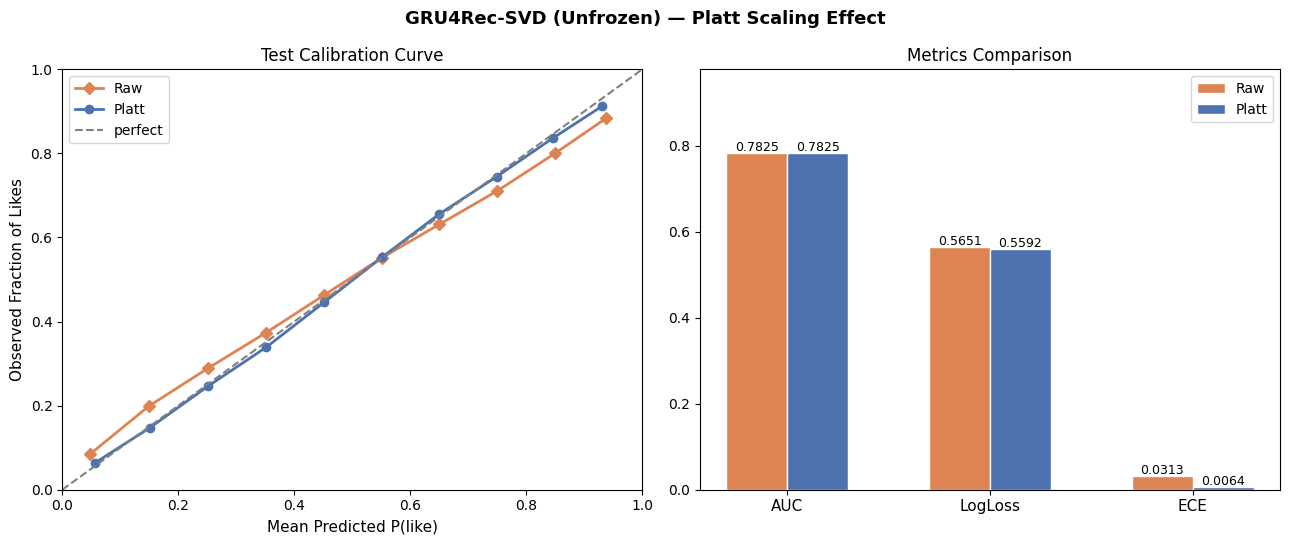

In [18]:
# ── Platt Scaling for GRU4Rec-SVD Unfrozen ───────────────────
# Fit σ(a·logit + b) on val predictions, apply to test predictions,
# then plot Raw vs Platt calibration curves (same style as XGBoost slide)
#
# Prerequisites: model_unfrozen, va_loader_comp, te_loader_comp,
#                res_unfrozen (from Phase 5 cells)

import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.calibration import calibration_curve
from sklearn.metrics import roc_auc_score, log_loss
import matplotlib.pyplot as plt

# ── Step 1: Get val predictions (for fitting Platt) ──────────
# Reuse the existing evaluate() function to get val predictions
print('Getting val predictions for Platt fitting...')
crit_platt = nn.BCEWithLogitsLoss()
res_val_unfrozen = evaluate(model_unfrozen, va_loader_comp, crit_platt, device)
val_probs  = res_val_unfrozen['probs']
val_labels = res_val_unfrozen['labels']
print(f'  Val samples: {len(val_probs):,}')
print(f'  Val AUC: {res_val_unfrozen["auc"]:.4f}')

# ── Step 2: Fit Platt scaling on val ─────────────────────────
# Platt scaling = logistic regression on log-odds (logit of raw prob)
# Clip to avoid log(0)
eps = 1e-7
val_logits = np.log(np.clip(val_probs, eps, 1 - eps) /
                    np.clip(1 - val_probs, eps, 1 - eps)).reshape(-1, 1)

platt = LogisticRegression(C=1e10, solver='lbfgs', max_iter=1000)
platt.fit(val_logits, val_labels)
print(f'  Platt params: a={platt.coef_[0][0]:.4f}, b={platt.intercept_[0]:.4f}')

# ── Step 3: Apply Platt to test predictions ──────────────────
test_probs_raw = res_unfrozen['probs']
test_labels    = res_unfrozen['labels']

test_logits = np.log(np.clip(test_probs_raw, eps, 1 - eps) /
                     np.clip(1 - test_probs_raw, eps, 1 - eps)).reshape(-1, 1)
test_probs_platt = platt.predict_proba(test_logits)[:, 1]

# ── Step 4: Compute metrics ──────────────────────────────────
auc_raw   = roc_auc_score(test_labels, test_probs_raw)
auc_platt = roc_auc_score(test_labels, test_probs_platt)
ll_raw    = log_loss(test_labels, test_probs_raw)
ll_platt  = log_loss(test_labels, test_probs_platt)

# ECE calculation
def compute_ece(labels, probs, n_bins=10):
    bin_edges = np.linspace(0, 1, n_bins + 1)
    ece = 0.0
    for i in range(n_bins):
        mask = (probs >= bin_edges[i]) & (probs < bin_edges[i + 1])
        if mask.sum() == 0:
            continue
        bin_acc  = labels[mask].mean()
        bin_conf = probs[mask].mean()
        ece += mask.sum() / len(probs) * abs(bin_acc - bin_conf)
    return ece

ece_raw   = compute_ece(test_labels, test_probs_raw)
ece_platt = compute_ece(test_labels, test_probs_platt)

print(f'\n{"─" * 55}')
print(f'  GRU4Rec-SVD Unfrozen — Raw vs Platt Scaling')
print(f'{"─" * 55}')
print(f'  {"Metric":<12} {"Raw":>10} {"Platt":>10} {"Δ":>10}')
print(f'  {"AUC":<12} {auc_raw:>10.4f} {auc_platt:>10.4f} {auc_platt-auc_raw:>+10.4f}')
print(f'  {"LogLoss":<12} {ll_raw:>10.4f} {ll_platt:>10.4f} {ll_platt-ll_raw:>+10.4f}')
print(f'  {"ECE":<12} {ece_raw:>10.4f} {ece_platt:>10.4f} {ece_platt-ece_raw:>+10.4f}')

# ── Step 5: Plot — Raw vs Platt Calibration Curves ───────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))
fig.suptitle('GRU4Rec-SVD (Unfrozen) — Platt Scaling Effect',
             fontsize=13, fontweight='bold')

# (Left) Calibration Curves
ax = axes[0]
for label_name, probs, color, marker in [
    ('Raw',   test_probs_raw,   '#DD8452', 'D'),
    ('Platt', test_probs_platt, '#4C72B0', 'o'),
]:
    frac_pos, mean_pred = calibration_curve(
        test_labels, probs, n_bins=10, strategy='uniform')
    ax.plot(mean_pred, frac_pos, f'-{marker}',
            color=color, lw=2, markersize=6, label=label_name)

ax.plot([0, 1], [0, 1], '--', color='gray', lw=1.5, label='perfect')
ax.set_xlabel('Mean Predicted P(like)', fontsize=11)
ax.set_ylabel('Observed Fraction of Likes', fontsize=11)
ax.set_title('Test Calibration Curve')
ax.legend(fontsize=10)
ax.set_xlim(0, 1); ax.set_ylim(0, 1)

# (Right) Metrics comparison bar chart
ax = axes[1]
x = np.arange(3)
width = 0.3
metrics_raw   = [auc_raw, ll_raw, ece_raw]
metrics_platt = [auc_platt, ll_platt, ece_platt]
metric_names  = ['AUC', 'LogLoss', 'ECE']

bars1 = ax.bar(x - width/2, metrics_raw,   width, label='Raw',   color='#DD8452', edgecolor='white')
bars2 = ax.bar(x + width/2, metrics_platt, width, label='Platt', color='#4C72B0', edgecolor='white')

for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f'{bar.get_height():.4f}', ha='center', fontsize=9)
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f'{bar.get_height():.4f}', ha='center', fontsize=9)

ax.set_xticks(x)
ax.set_xticklabels(metric_names, fontsize=11)
ax.set_title('Metrics Comparison')
ax.legend(fontsize=10)
ax.set_ylim(0, max(max(metrics_raw), max(metrics_platt)) * 1.25)

plt.tight_layout()
plt.show()

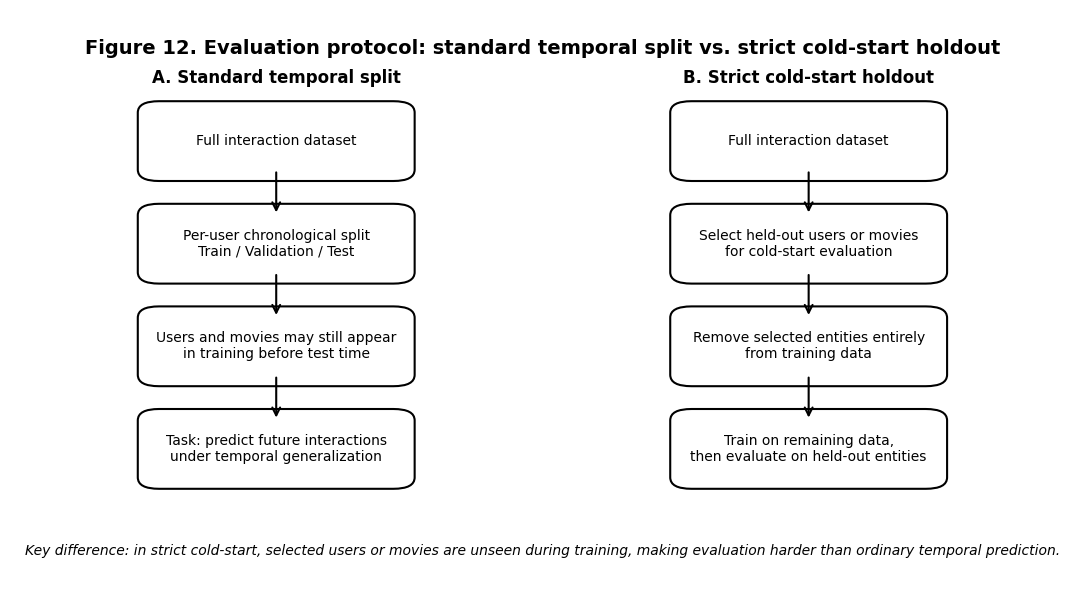

In [9]:
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch

def add_box(ax, xy, w, h, text, fontsize=10):
    x, y = xy
    box = FancyBboxPatch(
        (x, y), w, h,
        boxstyle="round,pad=0.02,rounding_size=0.02",
        linewidth=1.5,
        facecolor="white"
    )
    ax.add_patch(box)
    ax.text(
        x + w / 2, y + h / 2, text,
        ha="center", va="center",
        fontsize=fontsize, wrap=True
    )
    return box

def add_arrow(ax, start, end):
    arrow = FancyArrowPatch(
        start, end,
        arrowstyle="->",
        mutation_scale=14,
        linewidth=1.5
    )
    ax.add_patch(arrow)

fig, ax = plt.subplots(figsize=(12, 6))
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.axis("off")

# Title
ax.text(
    0.5, 0.95,
    "Figure 12. Evaluation protocol: standard temporal split vs. strict cold-start holdout",
    ha="center", va="top",
    fontsize=14, fontweight="bold"
)

# Column headers
ax.text(0.25, 0.88, "A. Standard temporal split", ha="center", va="center",
        fontsize=12, fontweight="bold")
ax.text(0.75, 0.88, "B. Strict cold-start holdout", ha="center", va="center",
        fontsize=12, fontweight="bold")

# Left column boxes
w, h = 0.22, 0.10
left_x = 0.14
ys = [0.72, 0.54, 0.36, 0.18]

add_box(ax, (left_x, ys[0]), w, h, "Full interaction dataset")
add_box(ax, (left_x, ys[1]), w, h, "Per-user chronological split\nTrain / Validation / Test")
add_box(ax, (left_x, ys[2]), w, h, "Users and movies may still appear\nin training before test time")
add_box(ax, (left_x, ys[3]), w, h, "Task: predict future interactions\nunder temporal generalization")

# Left arrows
for i in range(len(ys) - 1):
    add_arrow(ax,
              (left_x + w / 2, ys[i]),
              (left_x + w / 2, ys[i+1] + h))

# Right column boxes
right_x = 0.64

add_box(ax, (right_x, ys[0]), w, h, "Full interaction dataset")
add_box(ax, (right_x, ys[1]), w, h, "Select held-out users or movies\nfor cold-start evaluation")
add_box(ax, (right_x, ys[2]), w, h, "Remove selected entities entirely\nfrom training data")
add_box(ax, (right_x, ys[3]), w, h, "Train on remaining data,\nthen evaluate on held-out entities")

# Right arrows
for i in range(len(ys) - 1):
    add_arrow(ax,
              (right_x + w / 2, ys[i]),
              (right_x + w / 2, ys[i+1] + h))

# Bottom note
ax.text(
    0.5, 0.05,
    "Key difference: in strict cold-start, selected users or movies are unseen during training, "
    "making evaluation harder than ordinary temporal prediction.",
    ha="center", va="center",
    fontsize=10, style="italic", wrap=True
)

plt.tight_layout()
plt.show()

In [18]:
import pickle

torch.save(model_unfrozen.state_dict(), 'gru4rec_svd64_best.pt')
torch.save(svd_weight64, 'svd_weight64.pt')
pickle.dump(mid2idx, open('mid2idx_6140.pkl', 'wb'))

In [19]:
from google.colab import files

files.download('gru4rec_svd64_best.pt')
files.download('svd_weight64.pt')
files.download('mid2idx_6140.pkl')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>